In [1]:
!pip install optuna

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, PowerTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import mutual_info_regression
import warnings
warnings.filterwarnings("ignore")

RND = 42
np.random.seed(RND)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 31.7 MB/s eta 0:00:00


In [2]:
#  Utilities
def mse_from_sums(s, s2, n):
    if n <= 0:
        return 0.0
    mean = s / n
    return (s2 / n) - (mean * mean)

def candidate_thresholds_for_feature(Xf, max_candidates=50):
    vals = np.unique(Xf)
    if len(vals) <= max_candidates:
        return (vals[:-1] + vals[1:]) / 2.0
    else:
        qs = np.linspace(0, 1, max_candidates + 2)[1:-1]
        qvals = np.quantile(vals, qs)
        qvals = np.unique(qvals)
        if qvals.size <= 1:
            return np.array([])
        return (qvals[:-1] + qvals[1:]) / 2.0

def to_original_target(y_transformed):
    """Inverse of log1p transform"""
    return np.expm1(y_transformed)

def safe_rmse(y_true_original, y_pred_original):
    return np.sqrt(mean_squared_error(y_true_original, y_pred_original))


In [3]:
# Best split with limited candidate thresholds
def best_split_mse(X, y, feature_indices, max_candidates=40):
    n = len(y)
    best_feature, best_threshold, best_mse = None, None, float("inf")

    for feature in feature_indices:
        idx = np.argsort(X[:, feature])
        Xf = X[idx, feature]
        yf = y[idx]

        prefix_s = np.cumsum(yf)
        prefix_s2 = np.cumsum(yf * yf)

        total_s = prefix_s[-1]
        total_s2 = prefix_s2[-1]

        thresholds = candidate_thresholds_for_feature(Xf, max_candidates=max_candidates)
        if thresholds.size == 0:
            continue

        for thr in thresholds:
            i = np.searchsorted(Xf, thr, side='right')
            if i == 0 or i == n:
                continue

            left_n = i
            right_n = n - i
            left_s = prefix_s[i-1]
            left_s2 = prefix_s2[i-1]
            right_s = total_s - left_s
            right_s2 = total_s2 - left_s2

            mse_left = mse_from_sums(left_s, left_s2, left_n)
            mse_right = mse_from_sums(right_s, right_s2, right_n)

            weighted = (left_n/n)*mse_left + (right_n/n)*mse_right

            if weighted < best_mse:
                best_mse = weighted
                best_feature = feature
                best_threshold = thr

    return best_feature, best_threshold, best_mse


In [4]:

class FastCARTRegressor:
    def __init__(self, max_depth=8, min_samples_split=10, min_samples_leaf=5, max_features=None, reg_lambda=0.0):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.reg_lambda = reg_lambda
        self.root = None

    def fit(self, X, y):
        n, f = X.shape
        if self.max_features is None:
            self.max_features = max(1, int(np.sqrt(f)))
        self.root = self._grow(X, y, depth=0)
        return self

    def _grow(self, X, y, depth):
        n, f = X.shape
        if depth >= self.max_depth or n < self.min_samples_split or n <= self.min_samples_leaf:
            if n > 0:
                return {"leaf": np.sum(y) / (n + self.reg_lambda) if n + self.reg_lambda > 0 else np.mean(y)}
            else:
                return {"leaf": 0.0}

        feat_idx = np.random.choice(f, min(self.max_features, f), replace=False)
        feature, threshold, mse = best_split_mse(X, y, feat_idx, max_candidates=30)

        if feature is None:
            if n > 0:
                return {"leaf": np.sum(y) / (n + self.reg_lambda) if n + self.reg_lambda > 0 else np.mean(y)}
            else:
                return {"leaf": 0.0}

        left = X[:, feature] <= threshold
        right = ~left

        if left.sum() < self.min_samples_leaf or right.sum() < self.min_samples_leaf:
            if n > 0:
                return {"leaf": np.sum(y) / (n + self.reg_lambda) if n + self.reg_lambda > 0 else np.mean(y)}
            else:
                return {"leaf": 0.0}

        left_child = self._grow(X[left], y[left], depth+1)
        right_child = self._grow(X[right], y[right], depth+1)

        return {"feature": feature, "threshold": threshold, "left": left_child, "right": right_child}

    def _predict_one(self, x, node):
        if "leaf" in node:
            return node["leaf"]
        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self._predict_one(row, self.root) for row in X])


In [5]:
#  RandomForestRegressor
class RandomForestRegressor:
    def __init__(self, n_estimators=80, max_depth=8, min_samples_split=10, min_samples_leaf=5, max_features="sqrt", bootstrap=True):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.trees = []

    def _compute_max_features(self, n_features):
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(n_features)))
        elif self.max_features == "log2":
            return max(1, int(np.log2(n_features)))
        elif isinstance(self.max_features, int):
            return min(n_features, self.max_features)
        elif isinstance(self.max_features, float):
            return max(1, int(self.max_features * n_features))
        else:
            return n_features

    def fit(self, X, y):
        n, f = X.shape
        m_feats = self._compute_max_features(f)
        self.trees = []
        for _ in range(self.n_estimators):
            if self.bootstrap:
                idxs = np.random.choice(n, n, replace=True)
                X_s, y_s = X[idxs], y[idxs]
            else:
                X_s, y_s = X, y
            tree = FastCARTRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=m_feats
            )
            tree.fit(X_s, y_s)
            self.trees.append(tree)
        return self

    def predict(self, X):
        preds = np.array([tree.predict(X) for tree in self.trees])
        return preds.mean(axis=0)


In [6]:
#  GradientBoostingRegressor
class GradientBoostingRegressor:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, min_samples_split=10, min_samples_leaf=5,
                 subsample=0.8, colsample=0.8, reg_lambda=0.0, early_stopping_rounds=None):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.subsample = subsample
        self.colsample = colsample
        self.reg_lambda = reg_lambda
        self.early_stopping_rounds = early_stopping_rounds

        self.trees = []
        self.feature_subsets = []
        self.init_pred = None
        self.best_iteration = None

    def fit(self, X, y, X_val=None, y_val=None):
        n, f = X.shape
        self.init_pred = np.mean(y)
        pred = np.full(n, self.init_pred)
        best_val_loss = float("inf")
        patience = 0

        for i in range(self.n_estimators):
            residuals = y - pred
            if self.subsample < 1.0:
                idx = np.random.choice(n, int(self.subsample*n), replace=False)
                X_sub, r_sub = X[idx], residuals[idx]
            else:
                X_sub, r_sub = X, residuals

            m_feats = max(1, int(self.colsample * f))
            feat_idx = np.random.choice(f, m_feats, replace=False)

            tree = FastCARTRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                min_samples_leaf=self.min_samples_leaf,
                max_features=m_feats,
                reg_lambda=self.reg_lambda
            )
            tree.fit(X_sub[:, feat_idx], r_sub)
            update = tree.predict(X[:, feat_idx])
            pred += self.learning_rate * update
            self.trees.append(tree)
            self.feature_subsets.append(feat_idx)

            if X_val is not None and y_val is not None:
                val_pred = self.predict(X_val)
                val_loss = np.mean((y_val - val_pred)**2)
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    self.best_iteration = i
                    patience = 0
                else:
                    patience += 1
                if self.early_stopping_rounds and patience >= self.early_stopping_rounds:
                    print(f"Early stopping at iteration {i}, best iteration = {self.best_iteration}")
                    break
        return self

    def predict(self, X):
        if self.init_pred is None:
            return np.zeros(X.shape[0])
        pred = np.full(X.shape[0], self.init_pred)
        for tree, feat_idx in zip(self.trees, self.feature_subsets):
            pred += self.learning_rate * tree.predict(X[:, feat_idx])
        return pred


In [7]:
#Deep Neural Network
class Deep_Neural_Network:
    def create(self, input_size, output_size, hidden_dims, output_type='regression',
               initializer='he', seed=None, activation='relu', leaky_relu_slope=0.1):
        self.layer_dims = [input_size] + hidden_dims + [output_size]
        self.W = {}
        self.b = {}
        self.activation = activation
        self.leaky_relu_slope = leaky_relu_slope
        self.initializer = initializer
        self.output_type = output_type
        self.L = len(self.layer_dims) - 1

        if seed is not None:
            np.random.seed(seed)

        for i in range(self.L):
            self.W[i+1] = np.random.randn(self.layer_dims[i+1], self.layer_dims[i]) * 0.01
            self.b[i+1] = np.zeros((self.layer_dims[i+1], 1))

        if self.initializer == 'xavier':
            for i in range(self.L):
                self.W[i+1] *= np.sqrt(1 / self.layer_dims[i])
        elif self.initializer == 'he':
            for i in range(self.L):
                self.W[i+1] *= np.sqrt(2 / self.layer_dims[i])

    def linear(self, X): return X
    def linear_grad(self, X): return np.ones_like(X)
    def sigmoid(self, X): return 1 / (1 + np.exp(-np.clip(X, -500, 500)))
    def sigmoid_grad(self, X): s = self.sigmoid(X); return s * (1 - s)
    def tanh(self, X): return np.tanh(X)
    def tanh_grad(self, X): return 1 - (np.tanh(X) ** 2)
    def relu(self, X): return np.maximum(0, X)
    def relu_grad(self, X): return (X > 0).astype(float)
    def lrelu(self, X): return np.where(X > 0, X, X * self.leaky_relu_slope)
    def lrelu_grad(self, X): return np.where(X > 0, 1, self.leaky_relu_slope)

    def forward_propagation(self, X):
        self.Z = {}
        self.A = {}
        self.A[0] = X
        for i in range(self.L - 1):
            self.Z[i+1] = np.matmul(self.W[i+1], self.A[i]) + self.b[i+1]
            if self.activation == 'linear':
                self.A[i+1] = self.linear(self.Z[i+1])
            elif self.activation == 'sigmoid':
                self.A[i+1] = self.sigmoid(self.Z[i+1])
            elif self.activation == 'tanh':
                self.A[i+1] = self.tanh(self.Z[i+1])
            elif self.activation == 'relu':
                self.A[i+1] = self.relu(self.Z[i+1])
            elif self.activation == 'lrelu':
                self.A[i+1] = self.lrelu(self.Z[i+1])

        self.Z[self.L] = np.matmul(self.W[self.L], self.A[self.L-1]) + self.b[self.L]
        if self.output_type == 'regression':
            self.A[self.L] = self.Z[self.L]
        else:
            self.A[self.L] = self.sigmoid(self.Z[self.L])
        return self.A

    def compute_cost(self, Y_pred, Y_true):
        m = Y_true.shape[1]
        cost = (1 / (2 * m)) * np.sum((Y_pred - Y_true) ** 2)
        if hasattr(self, 'regularizer') and self.regularizer == 'l2':
            l2_sum = sum(np.sum(self.W[i+1] ** 2) for i in range(self.L))
            cost += (self.regularizer_lambda / (2 * m)) * l2_sum
        return cost

    def backward_propagation(self, Y):
        self.dZ = {}
        self.dW = {}
        self.db = {}
        m = Y.shape[1]
        self.dZ[self.L] = self.A[self.L] - Y
        for i in range(self.L, 0, -1):
            self.dW[i] = (1 / m) * np.matmul(self.dZ[i], self.A[i-1].T)
            if hasattr(self, 'regularizer') and self.regularizer == 'l2':
                self.dW[i] += (self.regularizer_lambda / m) * self.W[i]
            self.db[i] = (1 / m) * np.sum(self.dZ[i], axis=1, keepdims=True)
            if i > 1:
                dA = np.matmul(self.W[i].T, self.dZ[i])
                if self.activation == 'linear':
                    self.dZ[i-1] = dA * self.linear_grad(self.A[i-1])
                elif self.activation == 'sigmoid':
                    self.dZ[i-1] = dA * self.sigmoid_grad(self.A[i-1])
                elif self.activation == 'tanh':
                    self.dZ[i-1] = dA * self.tanh_grad(self.A[i-1])
                elif self.activation == 'relu':
                    self.dZ[i-1] = dA * self.relu_grad(self.A[i-1])
                elif self.activation == 'lrelu':
                    self.dZ[i-1] = dA * self.lrelu_grad(self.A[i-1])
        return (self.dW, self.db)

    def train(self, X_train, Y_train, X_val, Y_val, optimizer='adam', regularizer_lambda=0.001, mini_batch_size=64,
              epochs=100, learning_rate=0.001, beta1=0.9, beta2=0.999, print_loss_freq=20, plot_loss=False):
        self.regularizer = 'l2'
        self.regularizer_lambda = regularizer_lambda
        self.Mw = {i+1: np.zeros_like(self.W[i+1]) for i in range(self.L)}
        self.Mb = {i+1: np.zeros_like(self.b[i+1]) for i in range(self.L)}
        self.Vw = {i+1: np.zeros_like(self.W[i+1]) for i in range(self.L)}
        self.Vb = {i+1: np.zeros_like(self.b[i+1]) for i in range(self.L)}

        train_cost, val_cost = [], []
        m = X_train.shape[1]
        t = 1

        for epoch in range(epochs):
            permutation = np.random.permutation(m)
            X_train_shuffled = X_train[:, permutation]
            Y_train_shuffled = Y_train[:, permutation]

            for i in range(0, m, mini_batch_size):
                X_batch = X_train_shuffled[:, i:i+mini_batch_size]
                Y_batch = Y_train_shuffled[:, i:i+mini_batch_size]
                self.forward_propagation(X_batch)
                self.backward_propagation(Y_batch)
                for j in range(1, self.L + 1):
                    self.Mw[j] = beta1 * self.Mw[j] + (1 - beta1) * self.dW[j]
                    self.Mb[j] = beta1 * self.Mb[j] + (1 - beta1) * self.db[j]
                    self.Vw[j] = beta2 * self.Vw[j] + (1 - beta2) * (self.dW[j] ** 2)
                    self.Vb[j] = beta2 * self.Vb[j] + (1 - beta2) * (self.db[j] ** 2)
                    Mw_corr = self.Mw[j] / (1 - beta1 ** t)
                    Mb_corr = self.Mb[j] / (1 - beta1 ** t)
                    Vw_corr = self.Vw[j] / (1 - beta2 ** t)
                    Vb_corr = self.Vb[j] / (1 - beta2 ** t)
                    self.W[j] -= learning_rate * Mw_corr / (np.sqrt(Vw_corr) + 1e-8)
                    self.b[j] -= learning_rate * Mb_corr / (np.sqrt(Vb_corr) + 1e-8)
                t += 1

            Y_pred_train = self.forward_propagation(X_train)[self.L]
            Y_pred_val = self.forward_propagation(X_val)[self.L]
            train_cost.append(self.compute_cost(Y_pred_train, Y_train))
            val_cost.append(self.compute_cost(Y_pred_val, Y_val))
            if (epoch + 1) % print_loss_freq == 0:
                print(f"Epoch {epoch+1}/{epochs} - train: {train_cost[-1]:.6f}, val: {val_cost[-1]:.6f}")

        if plot_loss:
            plt.figure(figsize=(8,4))
            plt.plot(range(1, epochs+1), train_cost, label='train')
            plt.plot(range(1, epochs+1), val_cost, label='val')
            plt.legend(); plt.show()

        return (train_cost, val_cost)

    def predict(self, X):
        A = self.forward_propagation(X)
        return A[self.L]


In [10]:
df = pd.read_csv("/content/Crop_production1.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

In [11]:
df.head()

,State_Name,Crop_Type,Crop,N,P,K,pH,rainfall,temperature,Area_in_hectares,Production_in_tons,Yield_ton_per_hec
0,andhra pradesh,kharif,cotton,120,40,20,5.46,654.34,29.266667,7300.0,9400.0,1.287671
1,andhra pradesh,kharif,horsegram,20,60,20,6.18,654.34,29.266667,3300.0,1000.0,0.303030
2,andhra pradesh,kharif,jowar,80,40,40,5.42,654.34,29.266667,10100.0,10200.0,1.009901
3,andhra pradesh,kharif,maize,80,40,20,5.62,654.34,29.266667,2800.0,4900.0,1.750000
4,andhra pradesh,kharif,moong,20,40,20,5.68,654.34,29.266667,1300.0,500.0,0.384615


In [12]:
def create_new_important_features(df):
    df = df.copy()
    eps = 1e-6
    df['N_P_ratio'] = df['N'] / (df['P'] + eps)
    df['N_K_ratio'] = df['N'] / (df['K'] + eps)
    df['P_K_ratio'] = df['P'] / (df['K'] + eps)
    df['NminusP'] = df['N'] - df['P']
    df['NminusK'] = df['N'] - df['K']
    df['PminusK'] = df['P'] - df['K']
    df['NPK_Total'] = df['N'] + df['P'] + df['K']
    df['NPK_mean'] = df[['N','P','K']].mean(axis=1)
    df['NPK_std'] = df[['N','P','K']].std(axis=1)
    df['NPK_cv'] = df['NPK_std'] / (df['NPK_mean'] + eps)
    df['Rain_x_Temp'] = df['rainfall'] * df['temperature']
    df['Rain_x_pH'] = df['rainfall'] * df['pH']
    df['Temp_x_pH'] = df['temperature'] * df['pH']
    df['Rain_x_N'] = df['rainfall'] * df['N']
    df['Rain_x_P'] = df['rainfall'] * df['P']
    df['Rain_x_K'] = df['rainfall'] * df['K']
    df['Temp_x_N'] = df['temperature'] * df['N']
    df['Temp_x_P'] = df['temperature'] * df['P']
    df['Temp_x_K'] = df['temperature'] * df['K']
    df['pH_sq'] = df['pH'] ** 2
    df['Temp_sq'] = df['temperature'] ** 2
    df['Rain_sq'] = df['rainfall'] ** 2
    df['Area_sqrt'] = np.sqrt(df['Area_in_hectares'])
    df['Area_log'] = np.log1p(df['Area_in_hectares'])
    df['High_rain_stress'] = (df['rainfall'] > df['rainfall'].median()).astype(int)
    df['High_temp_stress'] = (df['temperature'] > df['temperature'].median()).astype(int)
    df['pH_stress'] = ((df['pH'] < 5.5) | (df['pH'] > 8)).astype(int)
    df['Area_x_Rain'] = df['Area_in_hectares'] * df['rainfall']
    df['Area_x_Temp'] = df['Area_in_hectares'] * df['temperature']
    df['Area_x_pH'] = df['Area_in_hectares'] * df['pH']
    return df

In [13]:
df_new = create_new_important_features(df)

In [14]:
df.shape

(99849, 12)

In [15]:
df.describe()

,N,P,K,pH,rainfall,temperature,Area_in_hectares,Production_in_tons,Yield_ton_per_hec
count,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,99849.000000,9.984900e+04,99849.000000
mean,69.816823,41.593656,42.037827,5.643624,701.151085,26.684154,16476.585668,3.776291e+04,3.931149
std,39.571469,15.056508,28.430263,0.505283,604.701552,4.851214,43604.268231,1.222447e+05,33.872242
min,10.000000,10.000000,10.000000,3.820000,3.274569,1.180000,0.580000,0.000000e+00,0.000000
25%,50.000000,40.000000,20.000000,5.360000,157.310000,23.106000,130.000000,1.620000e+02,0.586207
50%,75.000000,40.000000,30.000000,5.540000,579.750000,27.333333,1010.000000,1.506000e+03,1.329268
75%,80.000000,60.000000,50.000000,5.960000,1110.780000,29.266667,8099.000000,1.439500e+04,2.997288
max,180.000000,125.000000,200.000000,7.000000,3322.060000,35.346667,726300.000000,3.530571e+06,9801.000000


In [16]:
df_new.head()

,State_Name,Crop_Type,Crop,N,P,K,pH,rainfall,temperature,Area_in_hectares,...,Temp_sq,Rain_sq,Area_sqrt,Area_log,High_rain_stress,High_temp_stress,pH_stress,Area_x_Rain,Area_x_Temp,Area_x_pH
0,andhra pradesh,kharif,cotton,120,40,20,5.46,654.34,29.266667,7300.0,...,856.537778,428160.8356,85.440037,8.895767,1,1,1,4776682.0,213646.666667,39858.0
1,andhra pradesh,kharif,horsegram,20,60,20,6.18,654.34,29.266667,3300.0,...,856.537778,428160.8356,57.445626,8.101981,1,1,0,2159322.0,96580.000000,20394.0
2,andhra pradesh,kharif,jowar,80,40,40,5.42,654.34,29.266667,10100.0,...,856.537778,428160.8356,100.498756,9.220390,1,1,1,6608834.0,295593.333333,54742.0
3,andhra pradesh,kharif,maize,80,40,20,5.62,654.34,29.266667,2800.0,...,856.537778,428160.8356,52.915026,7.937732,1,1,0,1832152.0,81946.666667,15736.0
4,andhra pradesh,kharif,moong,20,40,20,5.68,654.34,29.266667,1300.0,...,856.537778,428160.8356,36.055513,7.170888,1,1,0,850642.0,38046.666667,7384.0


In [17]:
categorical_cols = ["State_Name", "Crop_Type", "Crop"]
label_encoders = {}
for col in categorical_cols:
    if col in df_new.columns:
        le = LabelEncoder()
        df_new[col] = le.fit_transform(df_new[col].astype(str))
        label_encoders[col] = le

In [18]:
df_new.dropna(subset=['Production_in_tons'], inplace=True)

In [19]:
# Features/target
X = df_new.drop(columns=["Production_in_tons", "Yield_ton_per_hec"], errors="ignore")
y_orig = df_new["Production_in_tons"].values  # original target

In [20]:
# Split first (avoid leakage)
X_temp, X_test, y_temp, y_test_orig = train_test_split(X, y_orig, test_size=0.15, random_state=RND)
X_train, X_val, y_train_orig, y_val_orig = train_test_split(X_temp, y_temp, test_size=0.176, random_state=RND)

print("Shapes -> Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


Shapes -> Train: (69933, 40) Val: (14938, 40) Test: (14978, 40)


In [21]:
numeric_cols = [c for c in X_train.columns if X_train[c].dtype != 'object']



===== Skewness of Numeric Features =====
Area_x_Rain         7.899823
Area_x_Temp         4.789472
Area_in_hectares    4.716101
Area_x_pH           4.633989
Rain_sq             3.284151
Rain_x_K            3.109901
Rain_x_N            2.380354
Area_sqrt           2.263602
Rain_x_P            1.991148
Temp_x_K            1.772091
K                   1.755747
N_K_ratio           1.499569
N_P_ratio           1.484805
Rain_x_pH           1.200223
rainfall            1.156406
NPK_std             1.132187
NPK_Total           1.068576
NPK_mean            1.068576
Rain_x_Temp         1.061456
N                   0.917422
Temp_x_N            0.847896
pH_sq               0.777239
pH                  0.574797
P_K_ratio           0.496387
Crop_Type           0.478635
NPK_cv              0.357508
pH_stress           0.269798
NminusP             0.269229
Temp_x_P            0.211041
Temp_sq             0.122831
P                   0.110520
High_temp_stress    0.034525
High_rain_stress    0.014443
A

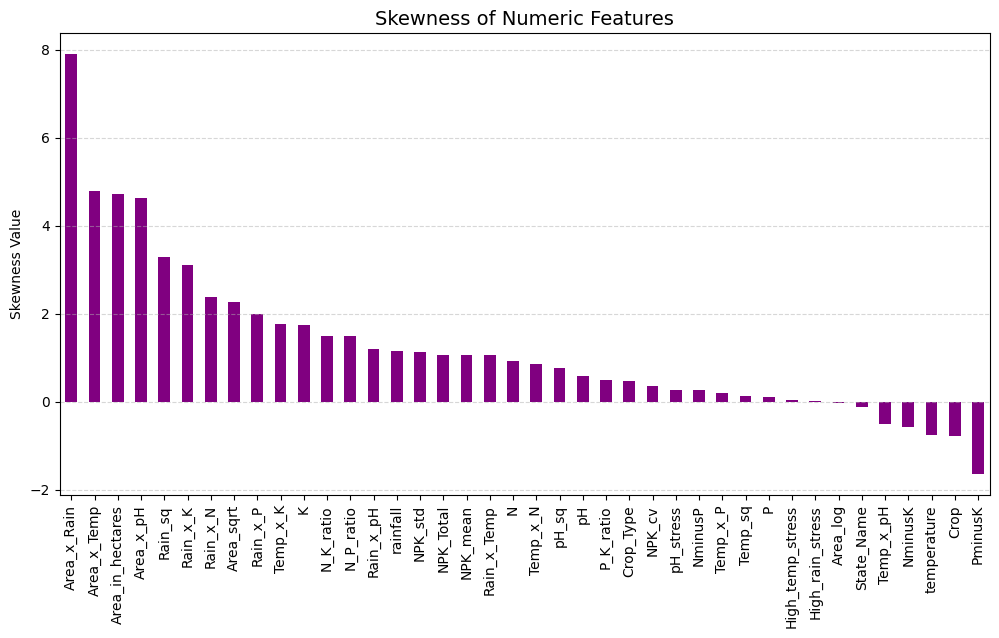

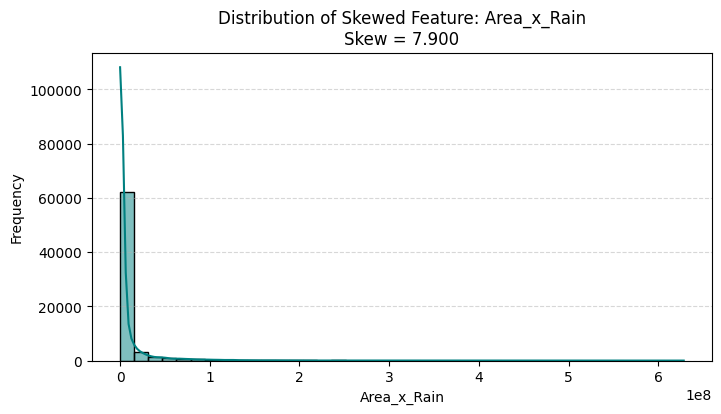

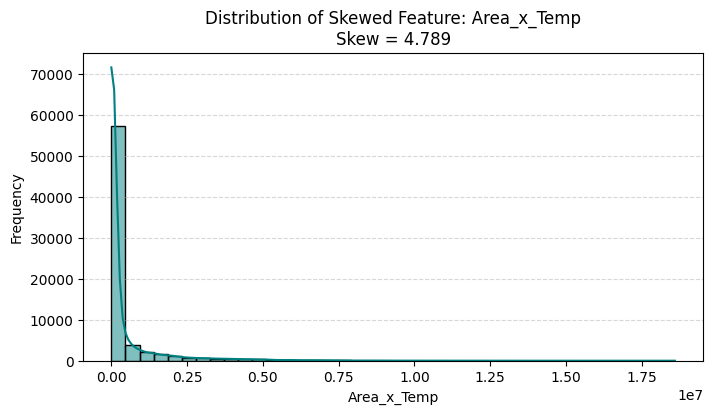

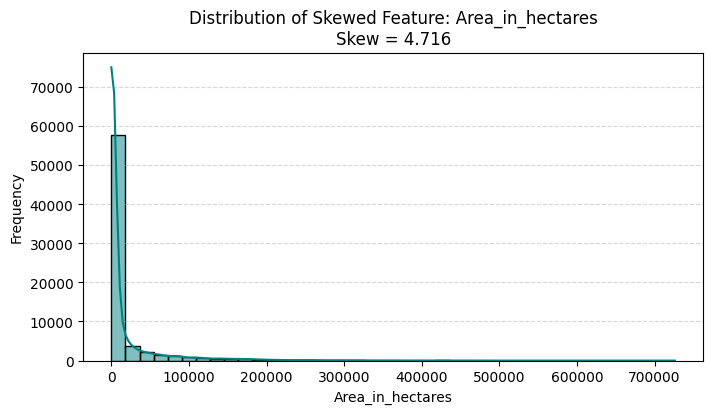

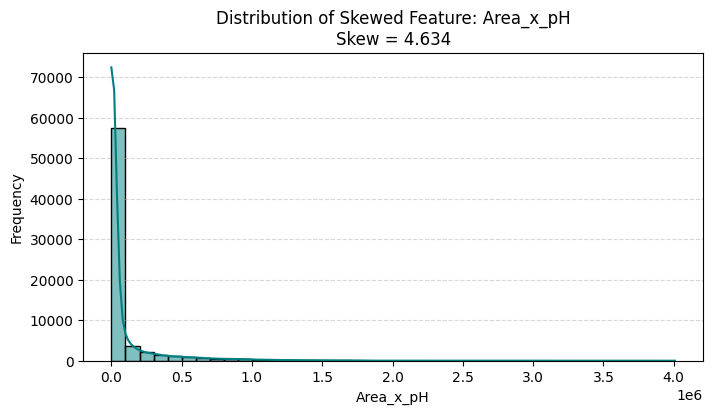

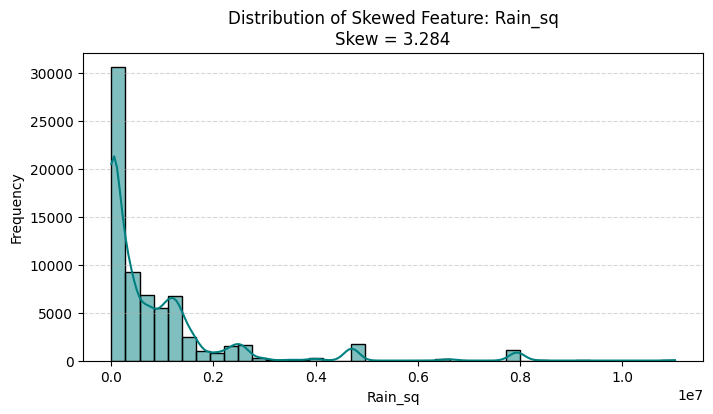

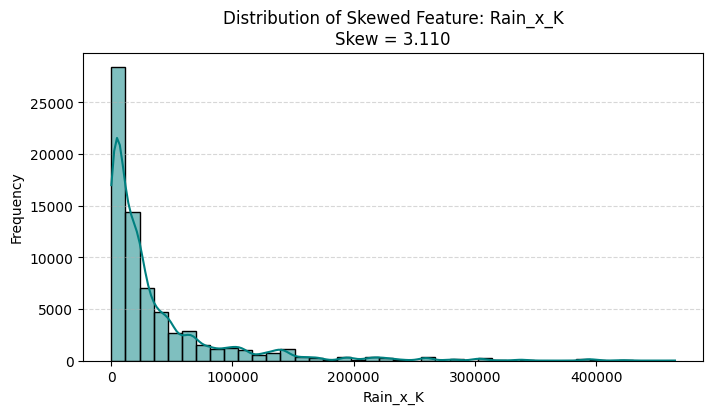

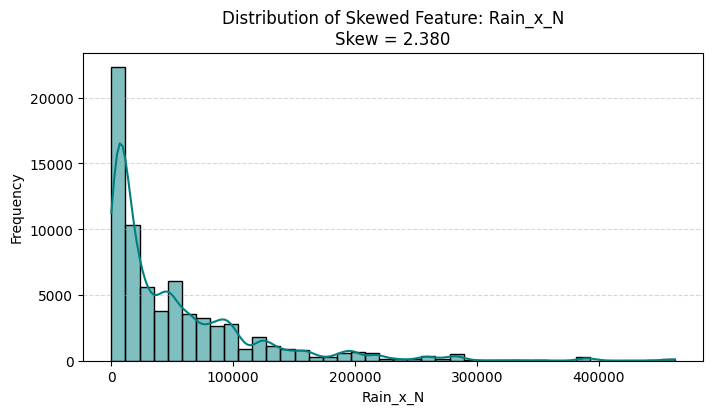

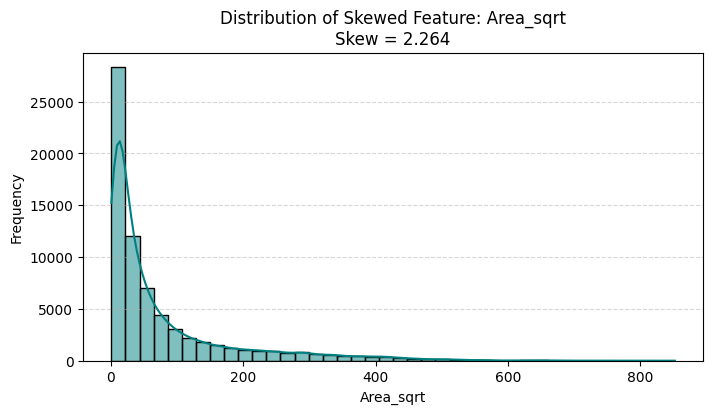

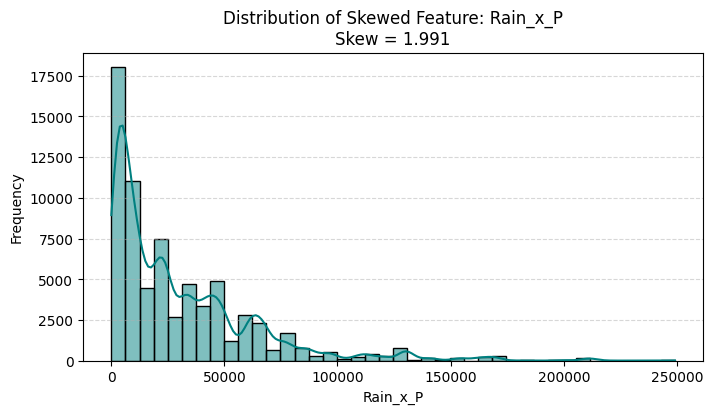

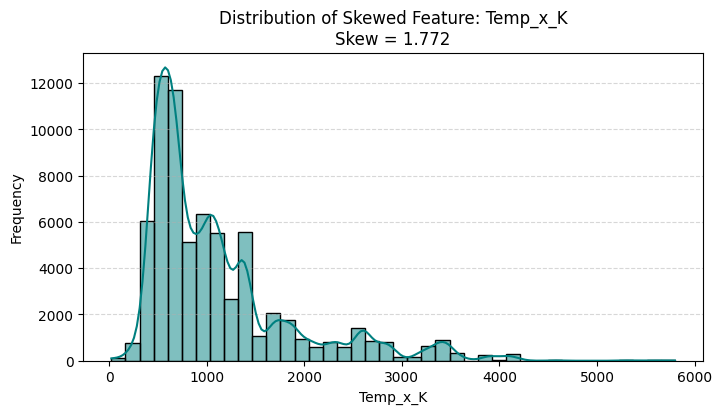

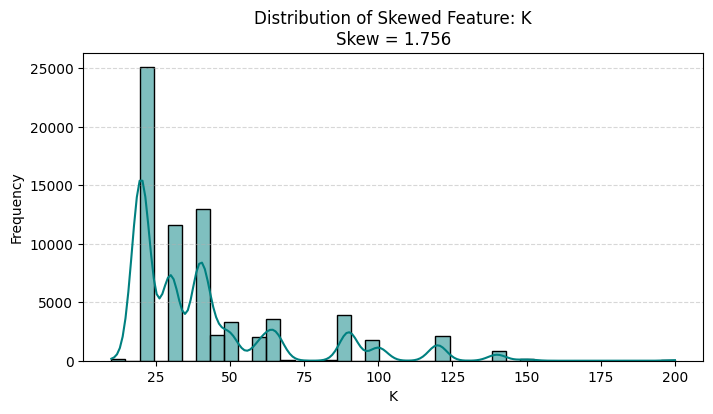

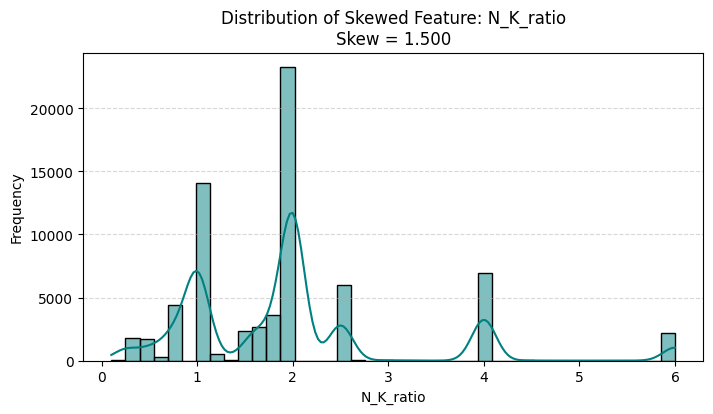

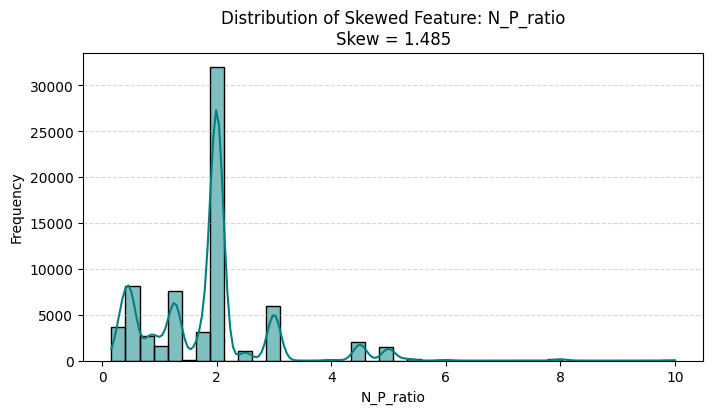

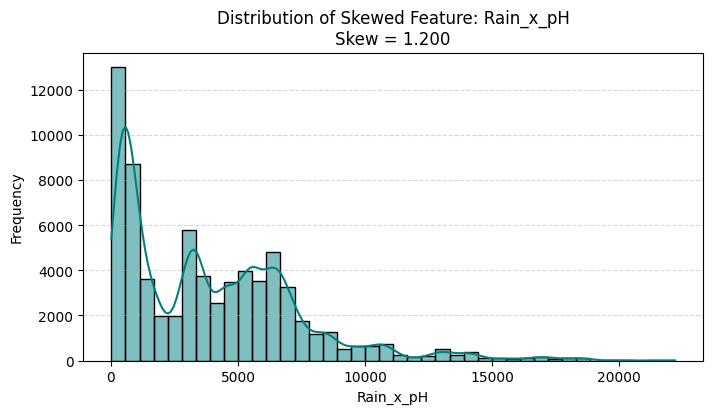

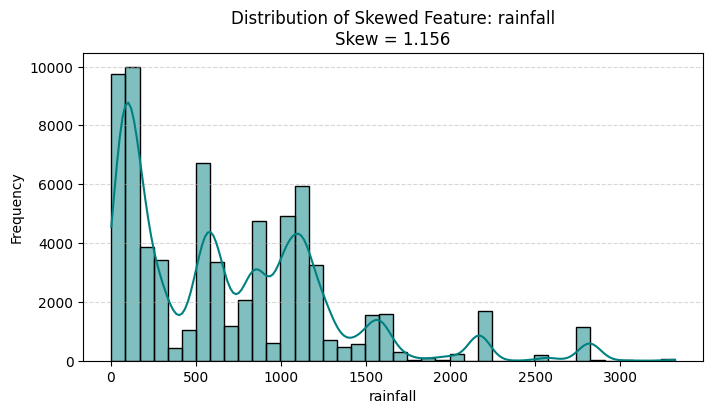

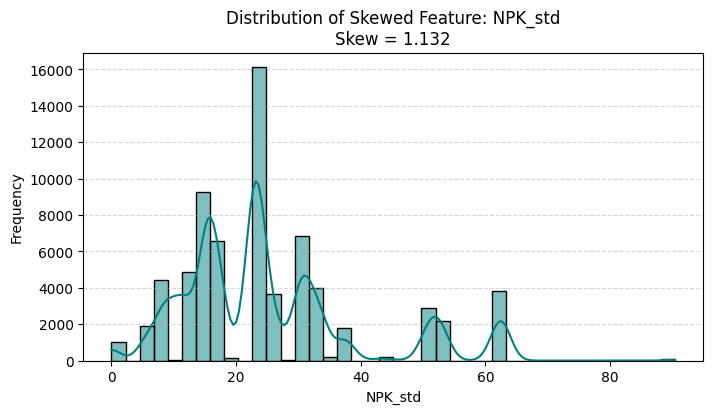

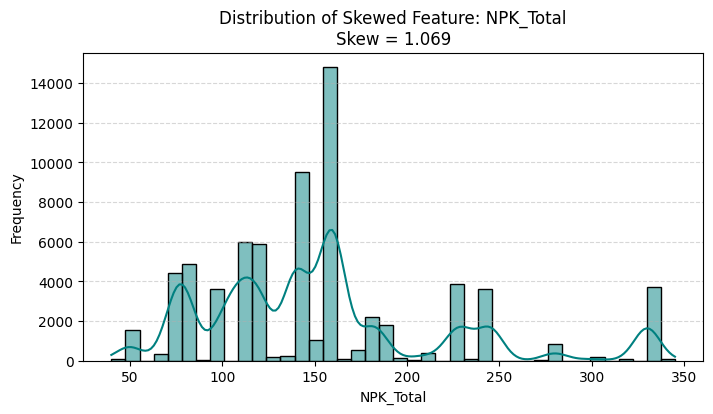

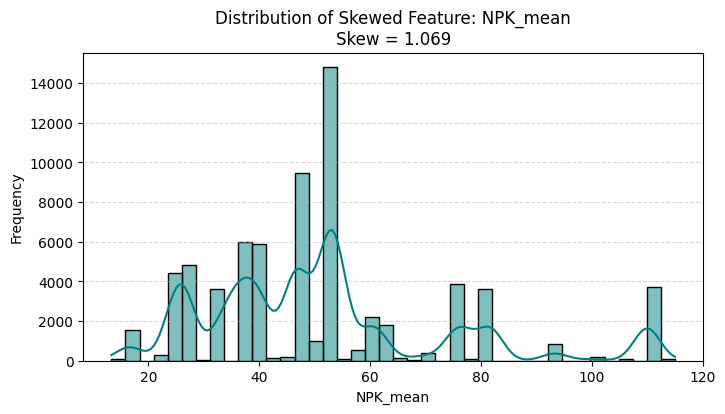

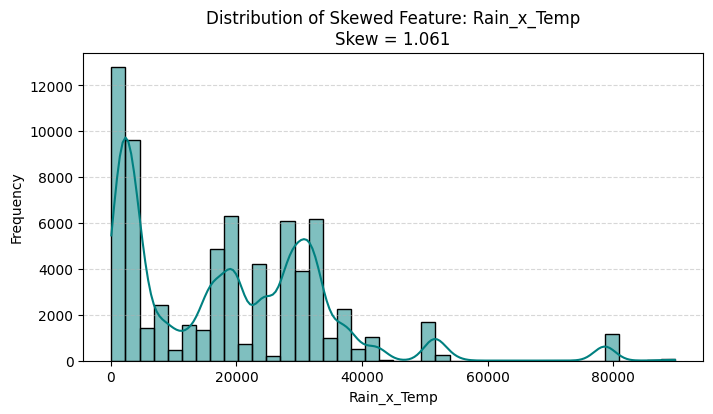

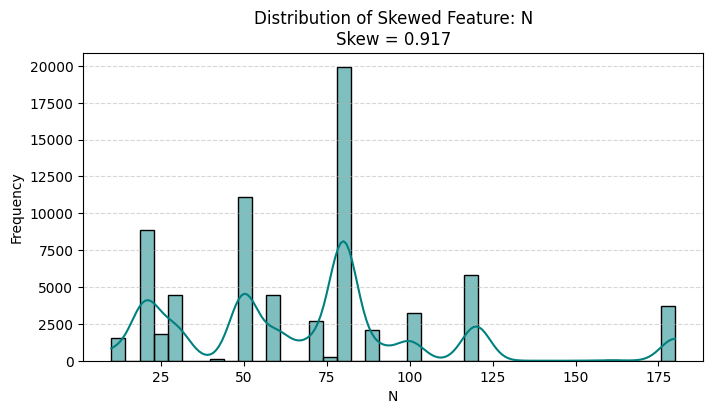

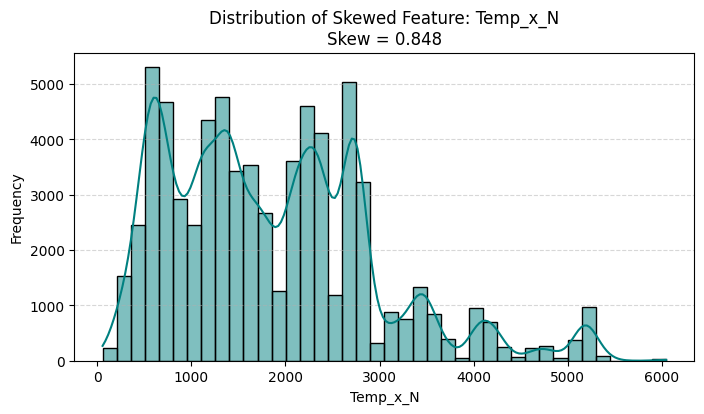

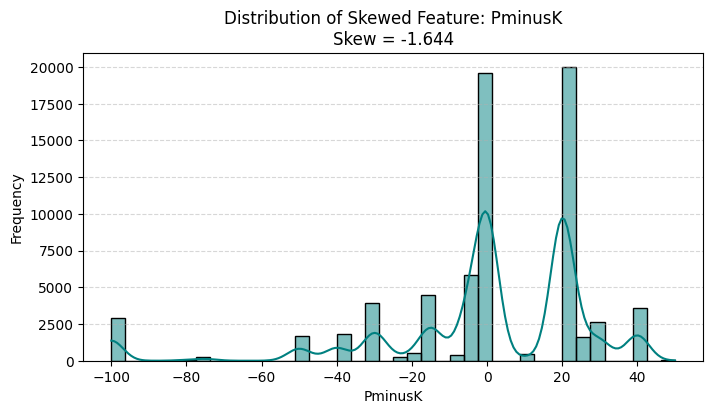

In [22]:

numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

skewness = X_train[numeric_cols].skew().sort_values(ascending=False)

# Select skewed features (absolute skew > 0.8)
skew_threshold = 0.8
skewed_features = skewness[skewness.abs() > skew_threshold].index.tolist()

print("\n===== Skewness of Numeric Features =====")
print(skewness)

print("\n===== Skewed Features (|skew| > 0.8) =====")
print(skewed_features)



plt.figure(figsize=(12, 6))
skewness.plot(kind='bar', color='purple')

plt.title("Skewness of Numeric Features", fontsize=14)
plt.ylabel("Skewness Value")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


for col in skewed_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[col], kde=True, bins=40, color='teal')

    plt.title(f"Distribution of Skewed Feature: {col}\nSkew = {skewness[col]:.3f}",
              fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()


In [25]:
# Fit PowerTransformer on training skewed columns only
pt = PowerTransformer(method='yeo-johnson')
if skewed_features:
    X_train[skewed_features] = pt.fit_transform(X_train[skewed_features])
    X_val[skewed_features] = pt.transform(X_val[skewed_features])
    X_test[skewed_features] = pt.transform(X_test[skewed_features])


In [26]:
# Standardize (fit on train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


NUMERIC FEATURES: ['State_Name', 'Crop_Type', 'Crop', 'N', 'P', 'K', 'pH', 'rainfall', 'temperature', 'Area_in_hectares', 'N_P_ratio', 'N_K_ratio', 'P_K_ratio', 'NminusP', 'NminusK', 'PminusK', 'NPK_Total', 'NPK_mean', 'NPK_std', 'NPK_cv', 'Rain_x_Temp', 'Rain_x_pH', 'Temp_x_pH', 'Rain_x_N', 'Rain_x_P', 'Rain_x_K', 'Temp_x_N', 'Temp_x_P', 'Temp_x_K', 'pH_sq', 'Temp_sq', 'Rain_sq', 'Area_sqrt', 'Area_log', 'High_rain_stress', 'High_temp_stress', 'pH_stress', 'Area_x_Rain', 'Area_x_Temp', 'Area_x_pH']


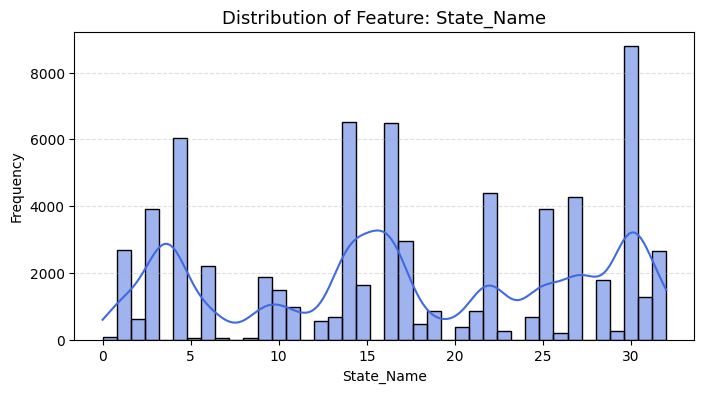

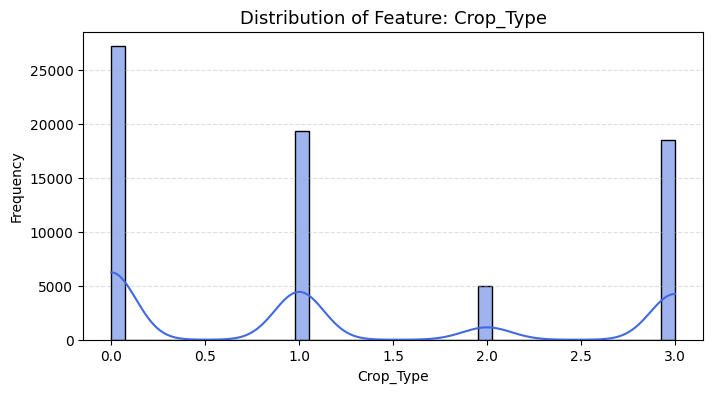

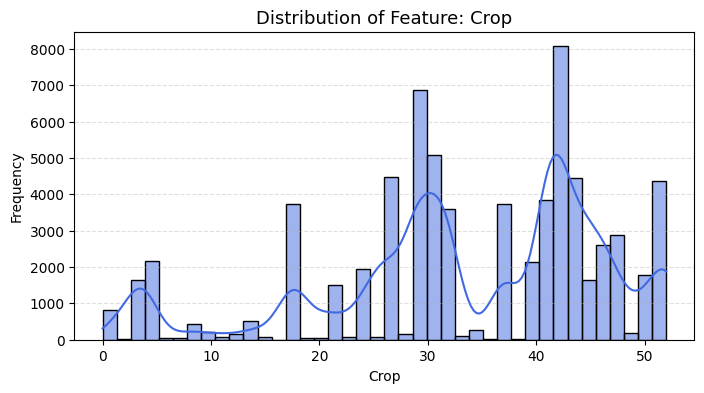

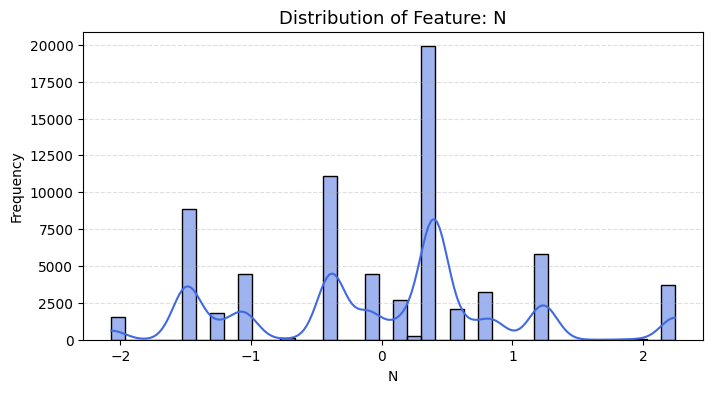

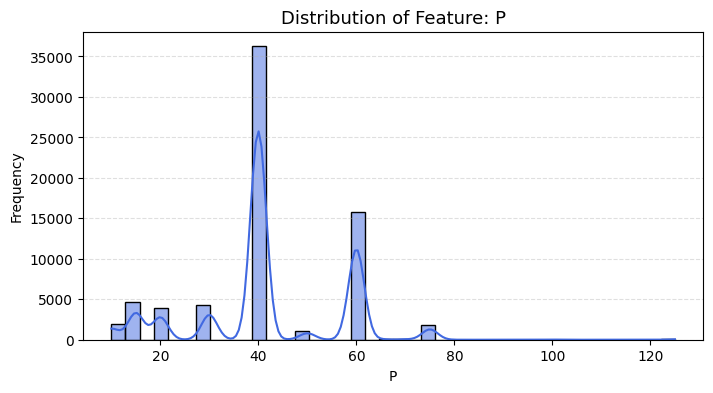

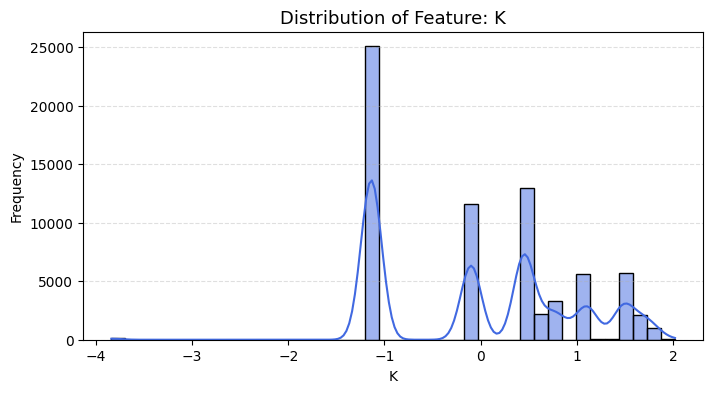

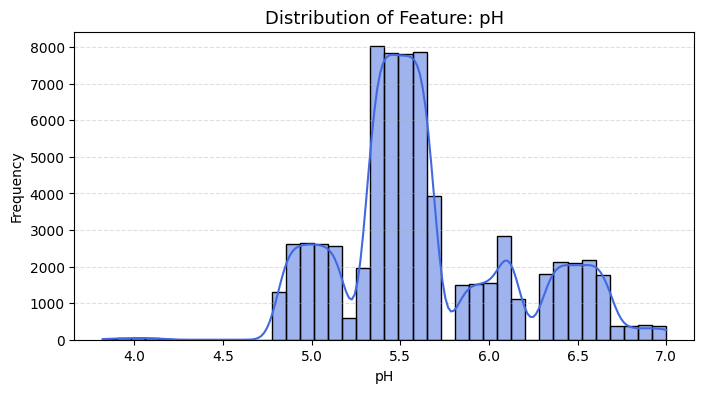

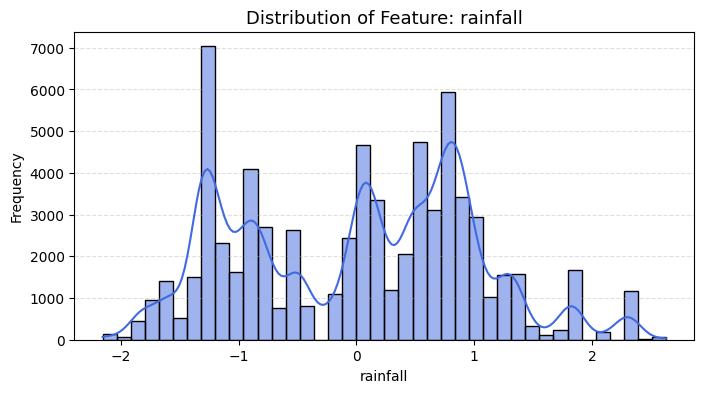

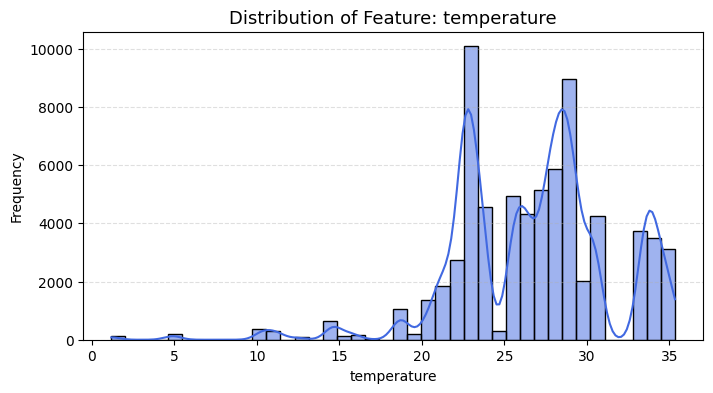

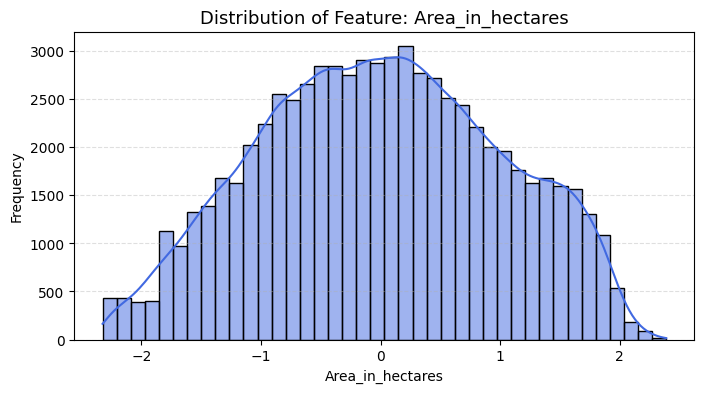

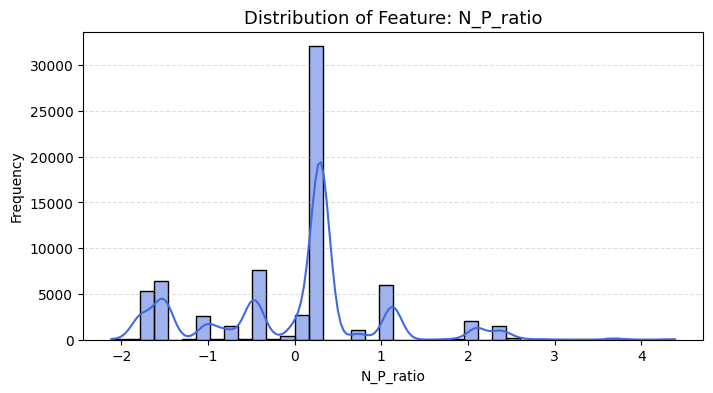

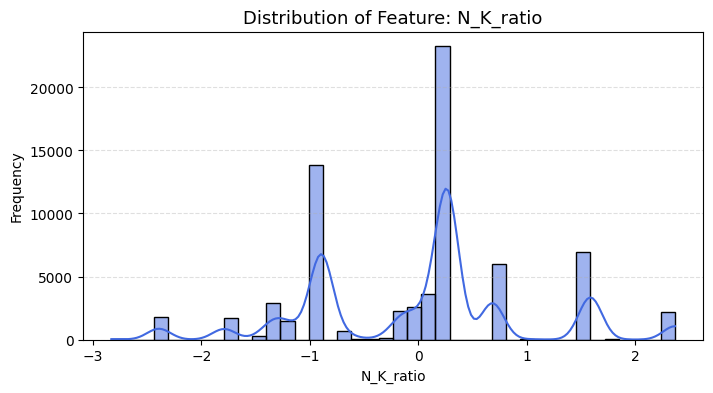

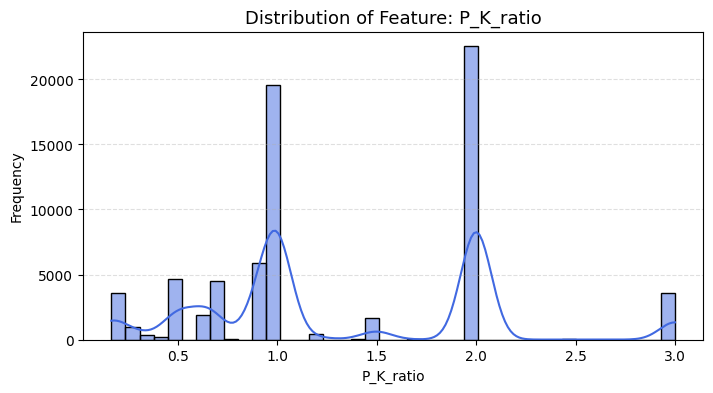

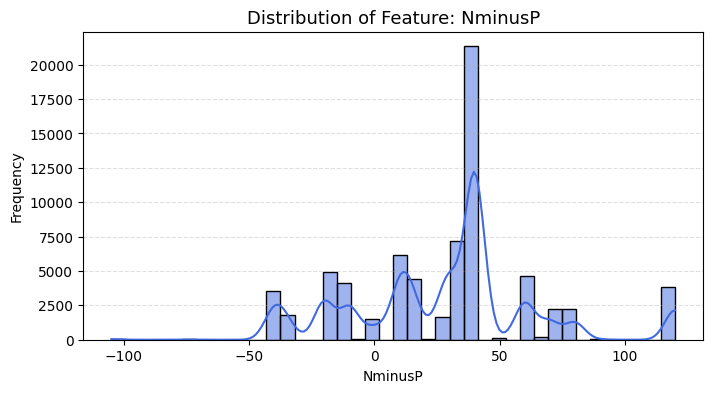

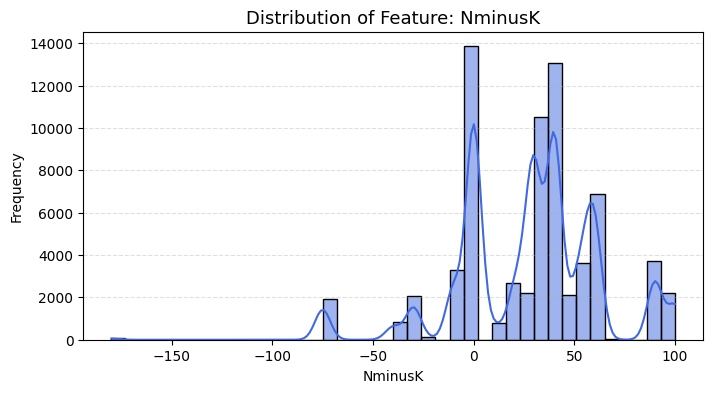

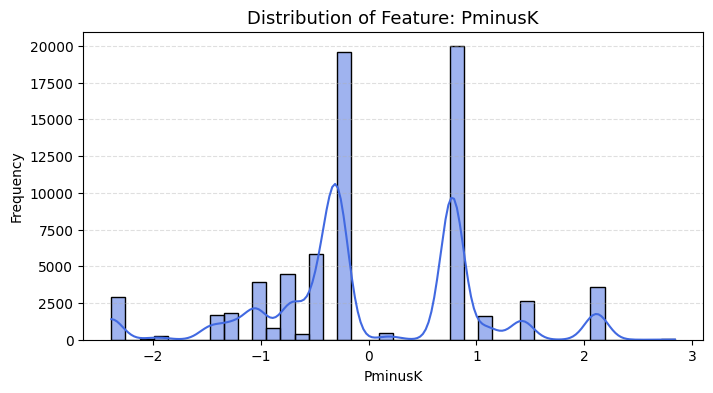

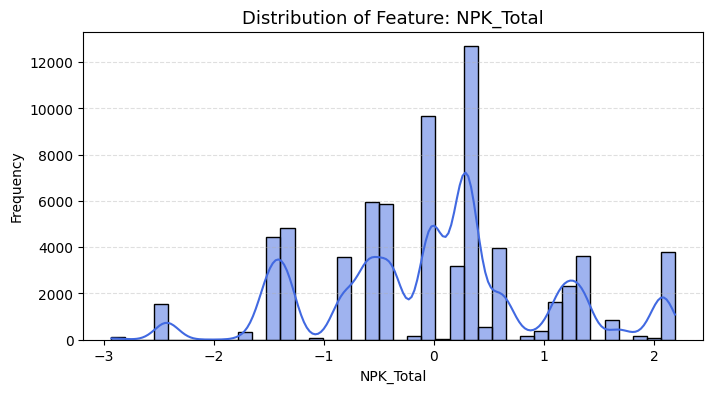

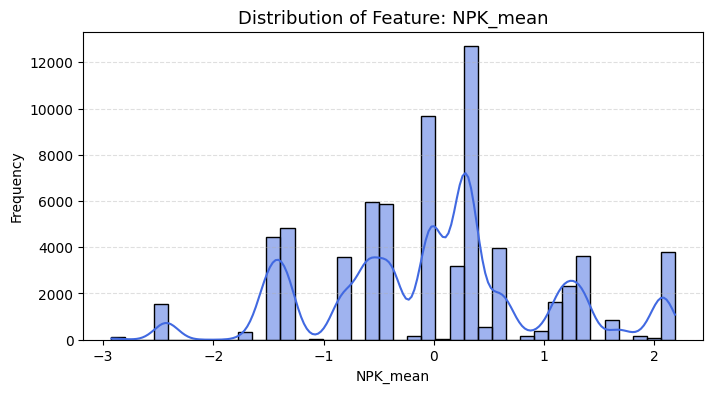

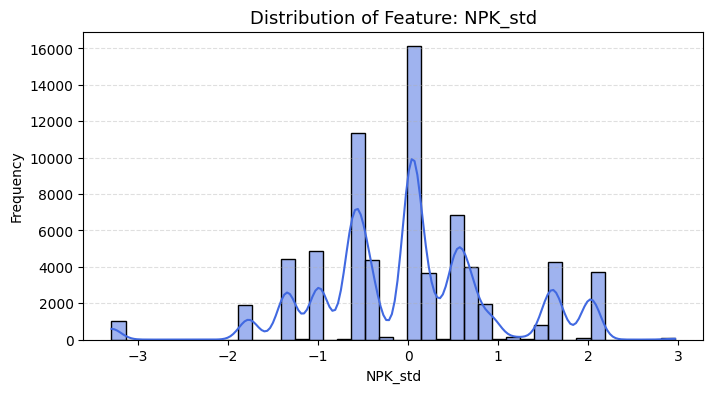

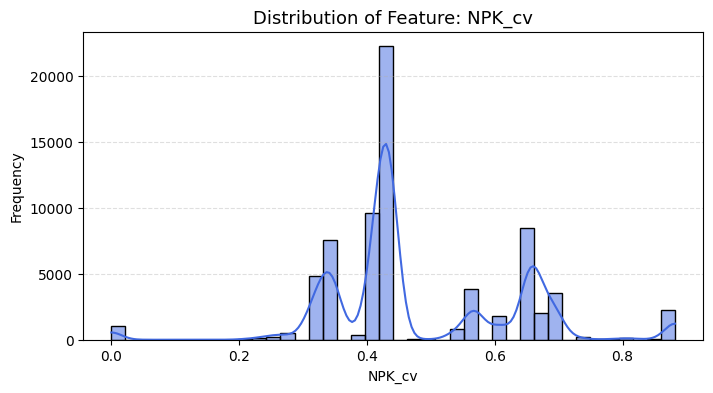

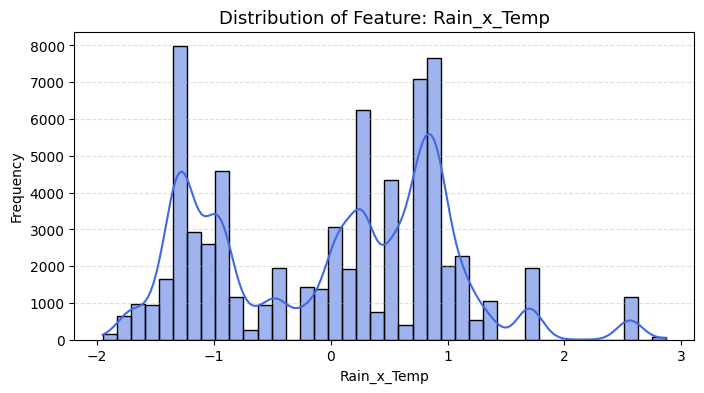

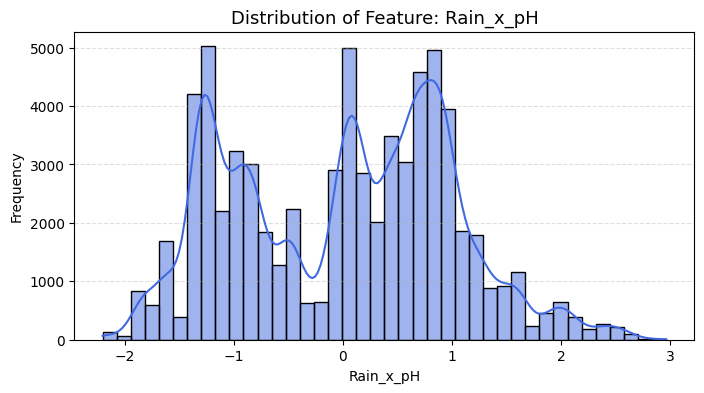

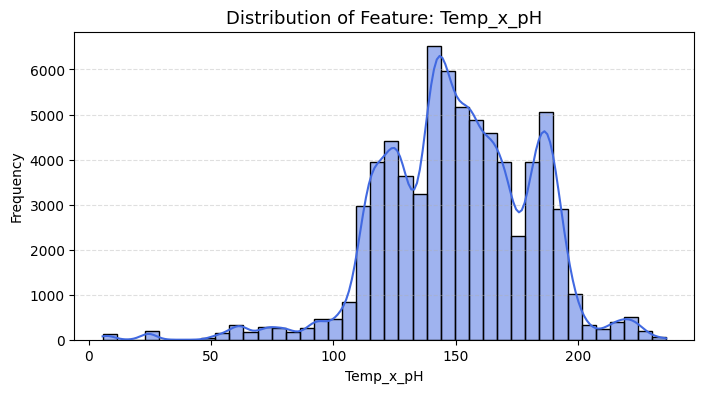

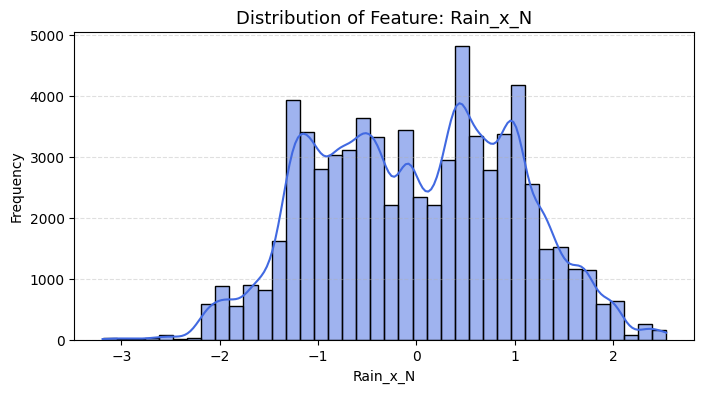

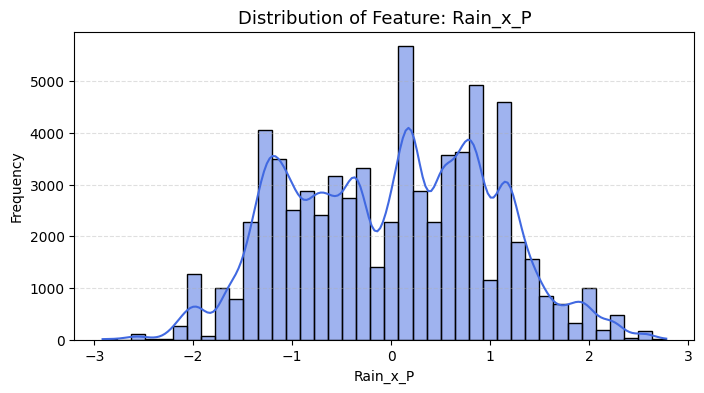

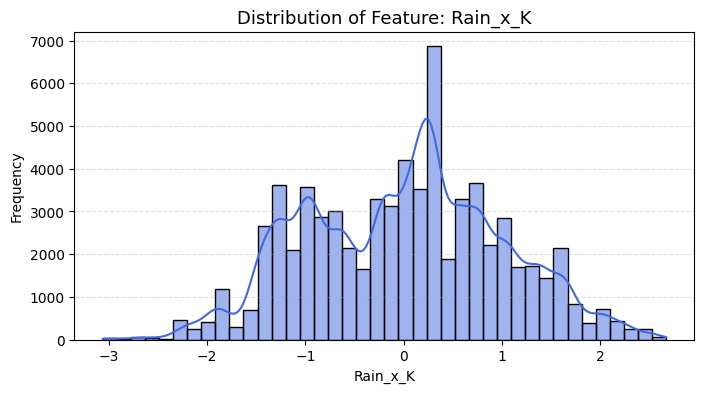

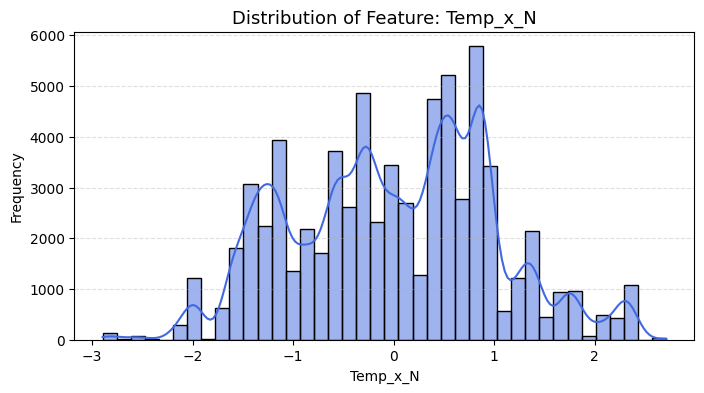

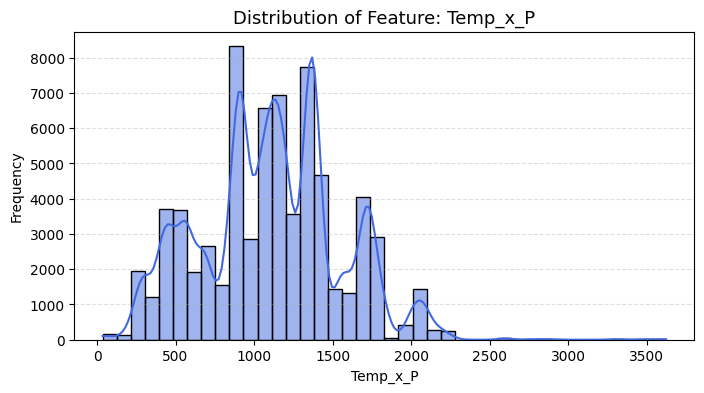

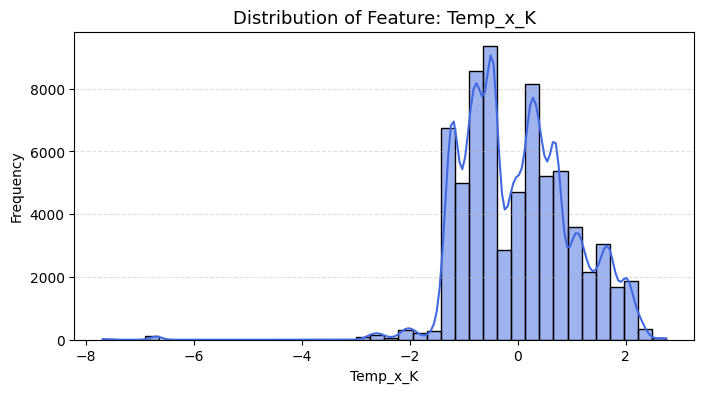

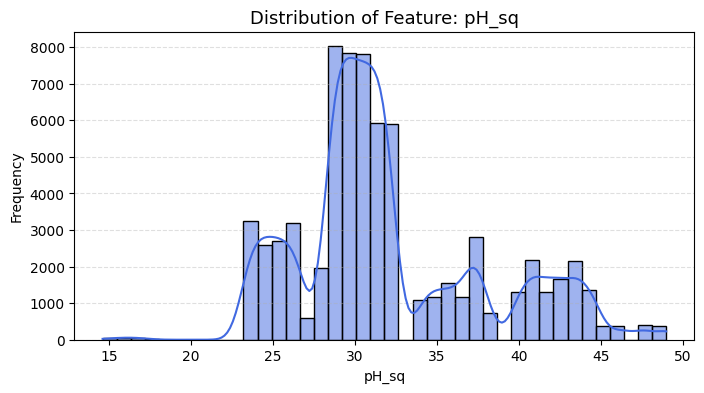

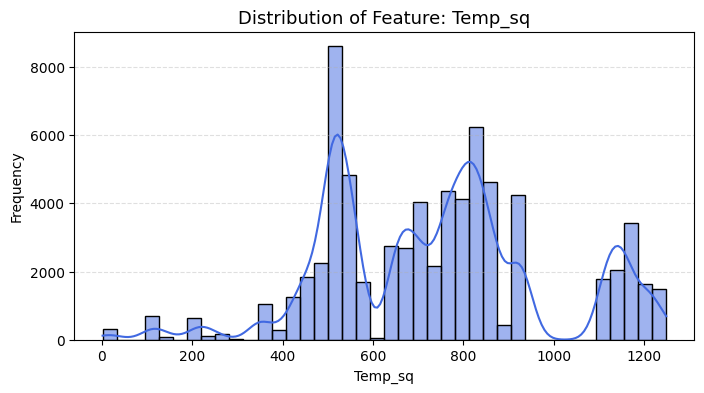

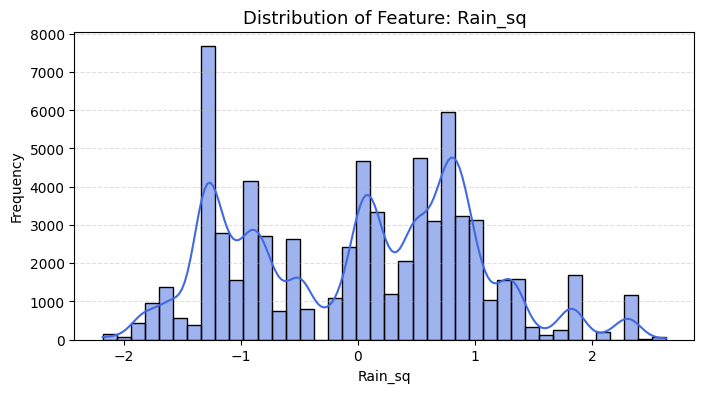

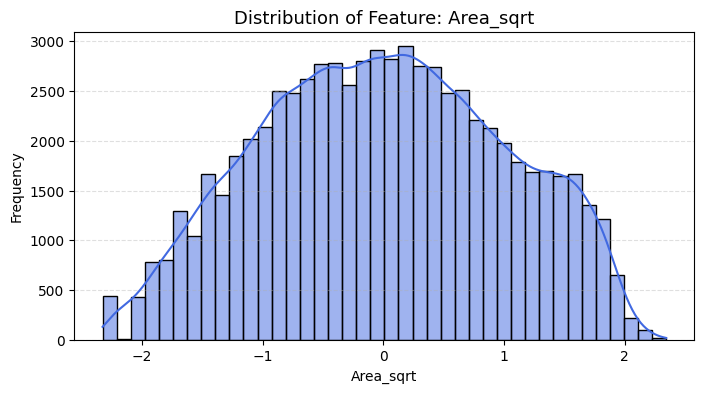

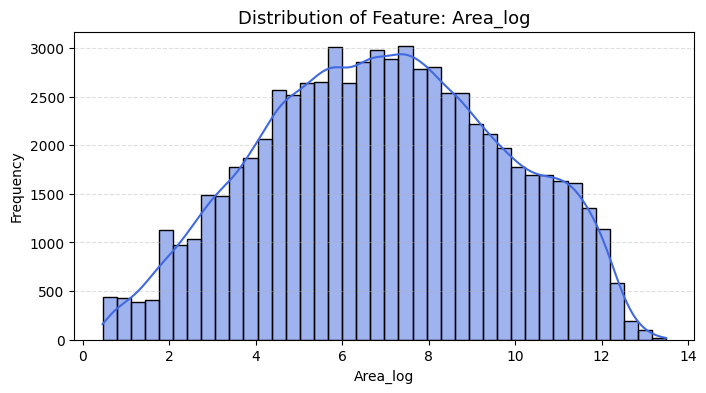

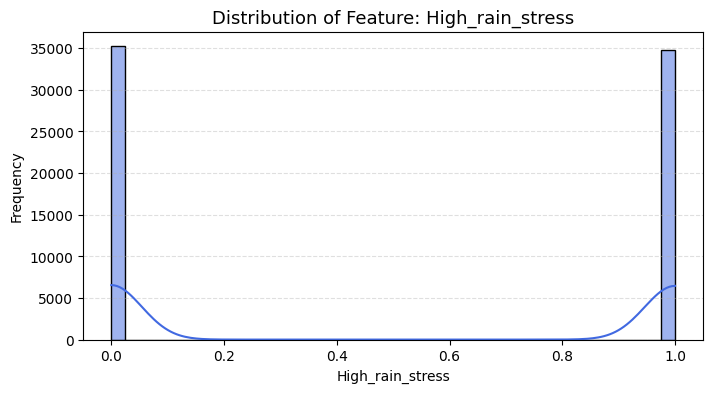

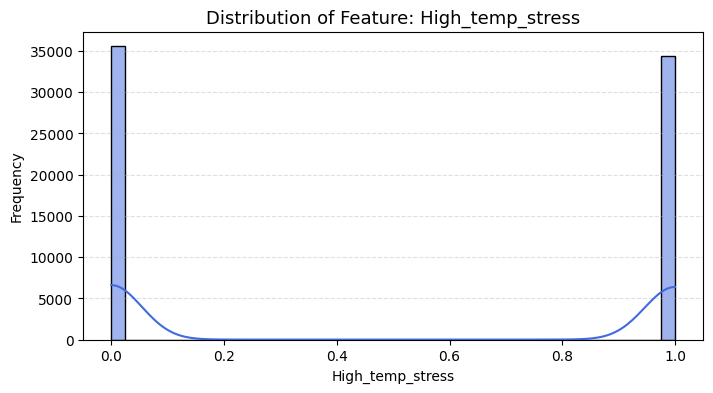

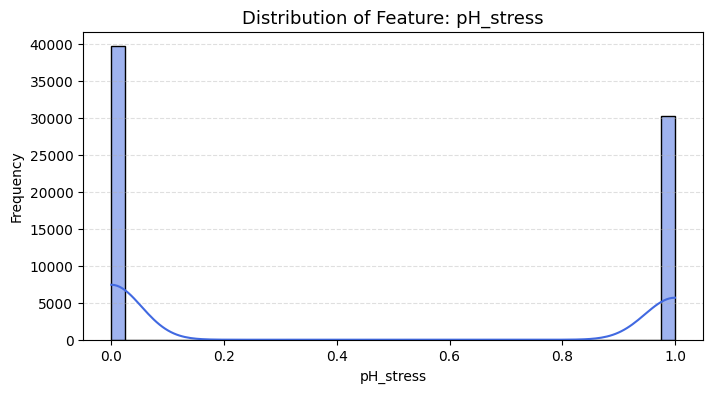

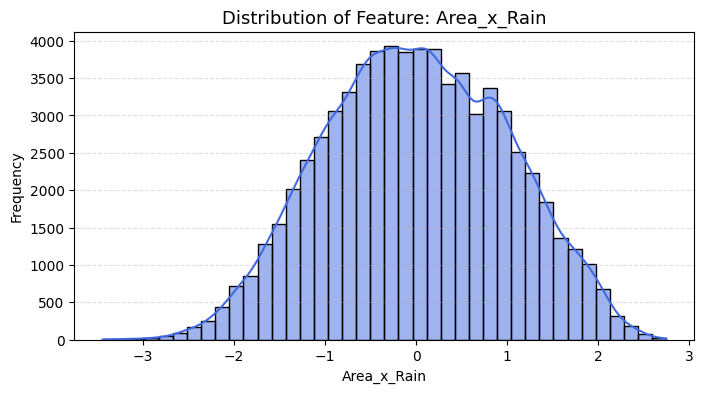

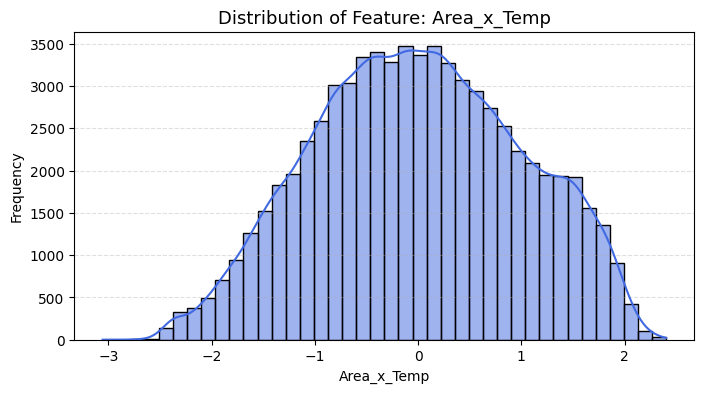

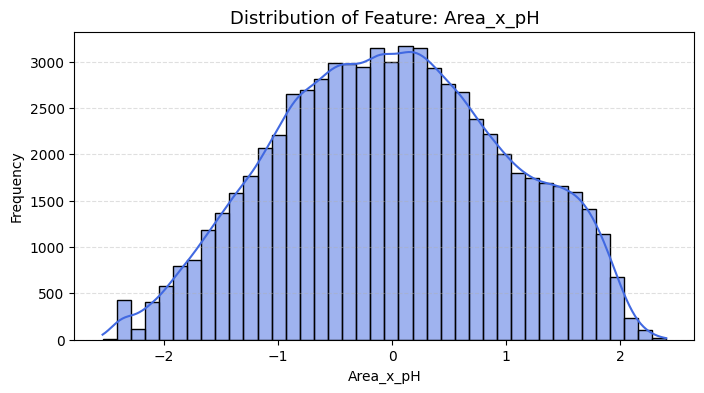

In [27]:
numeric_cols = X_train.columns   # since all columns are numeric now

print("\nNUMERIC FEATURES:", list(numeric_cols))

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(X_train[col], kde=True, bins=40, color='royalblue')

    plt.title(f"Distribution of Feature: {col}", fontsize=13)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.show()

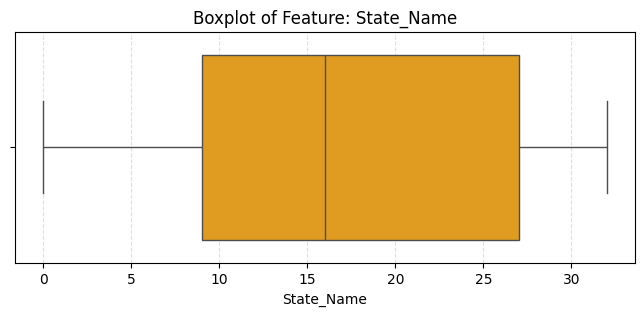

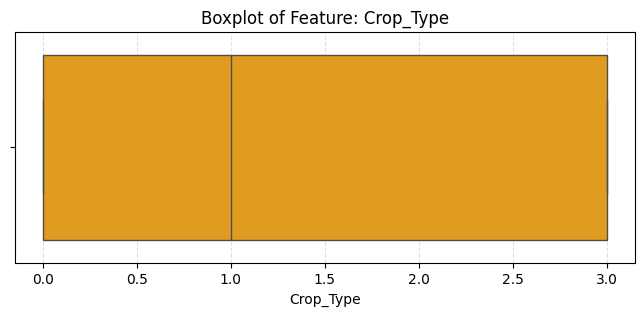

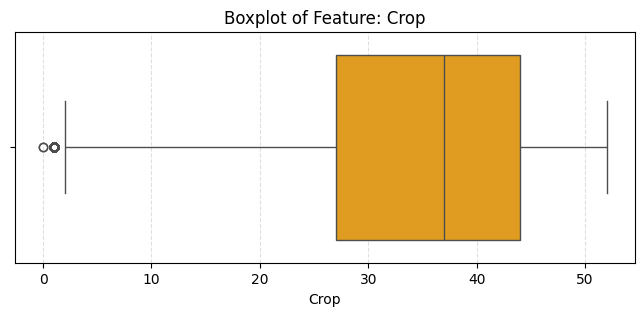

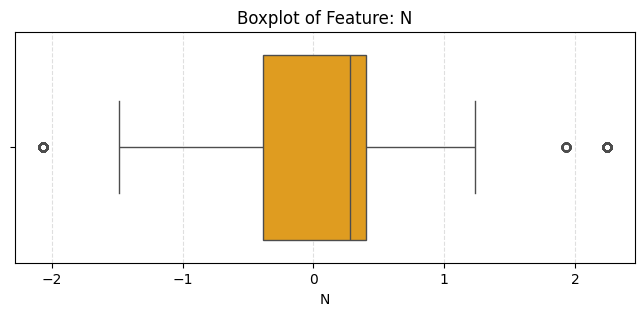

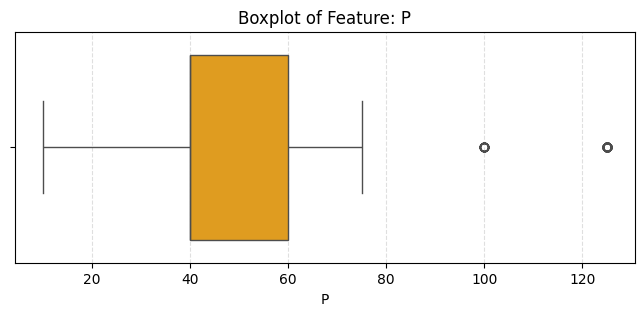

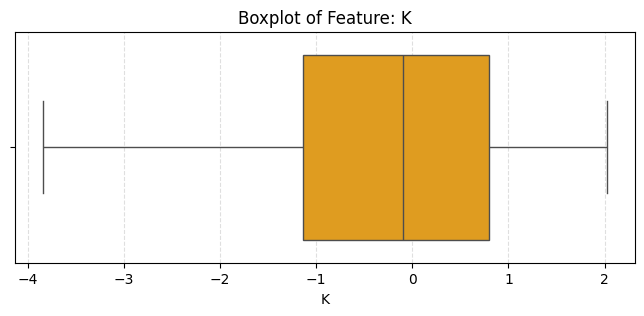

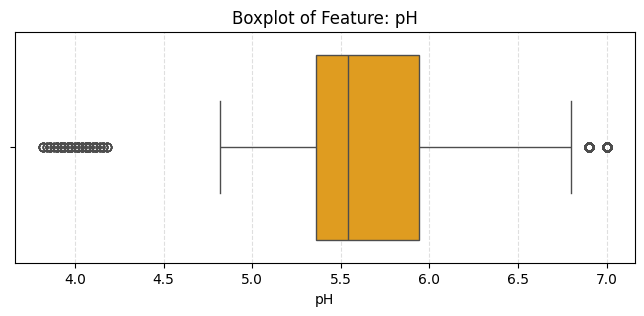

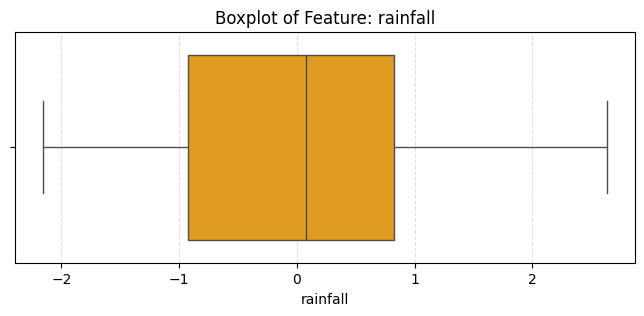

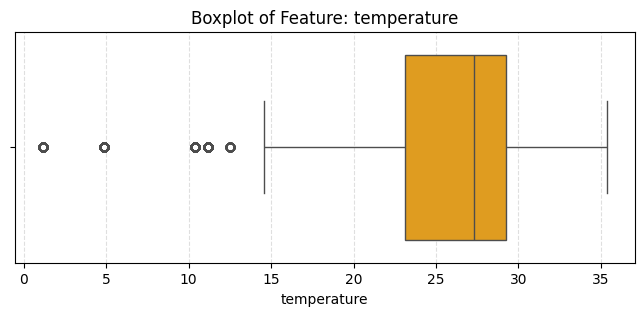

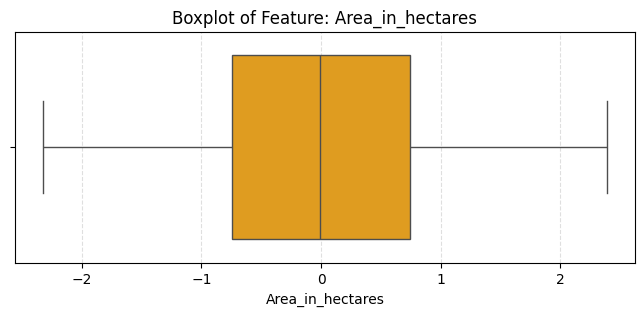

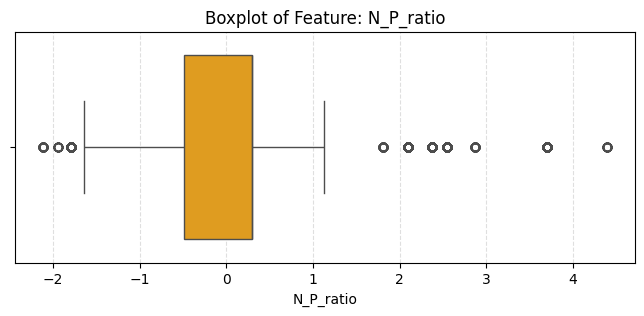

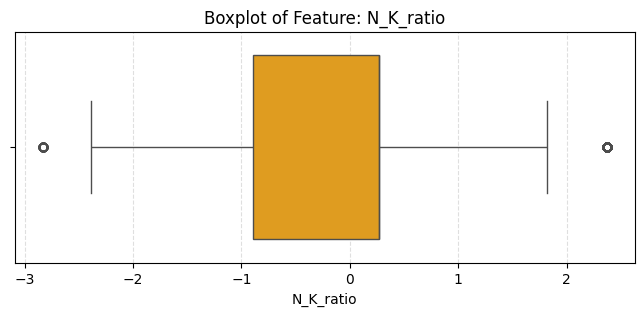

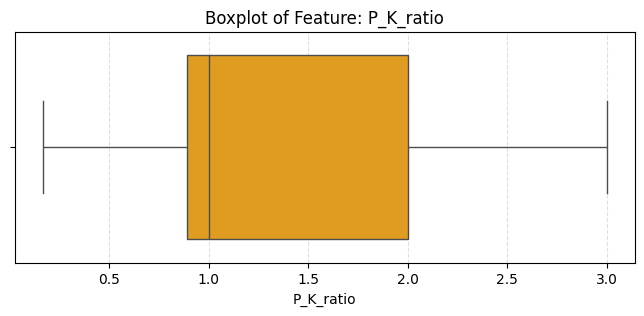

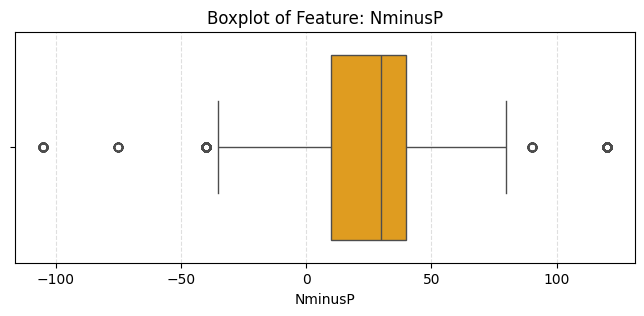

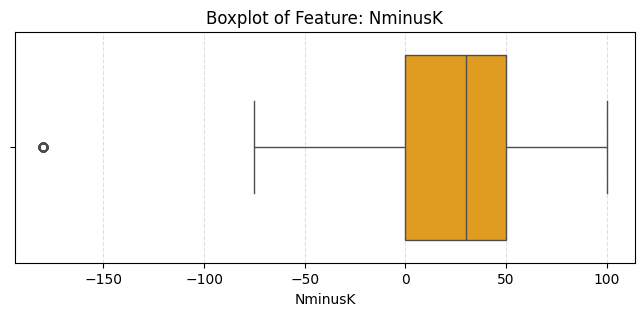

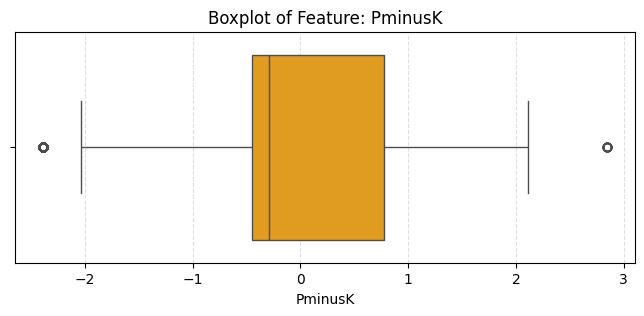

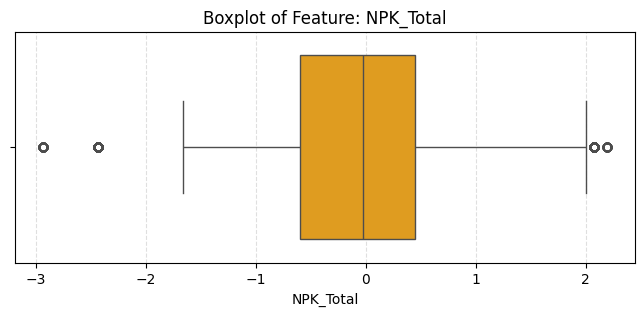

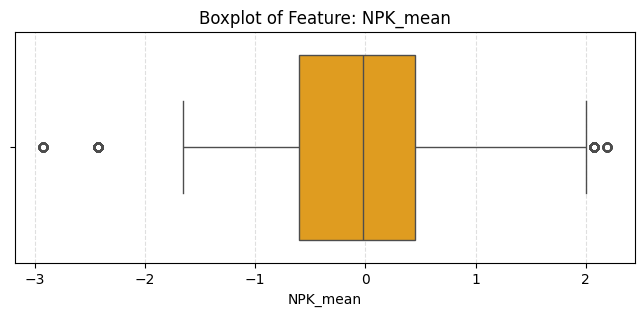

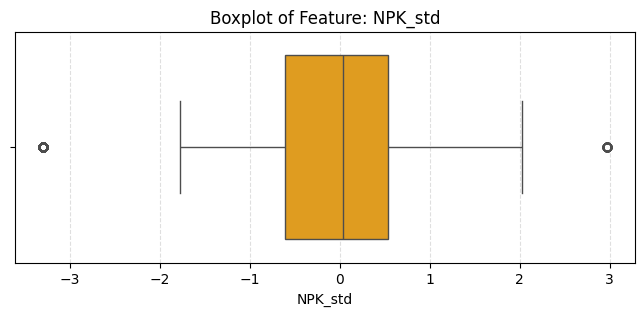

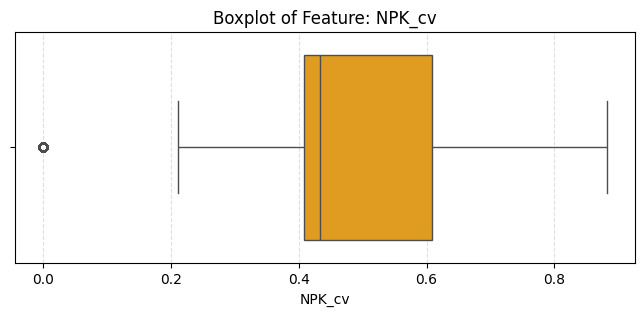

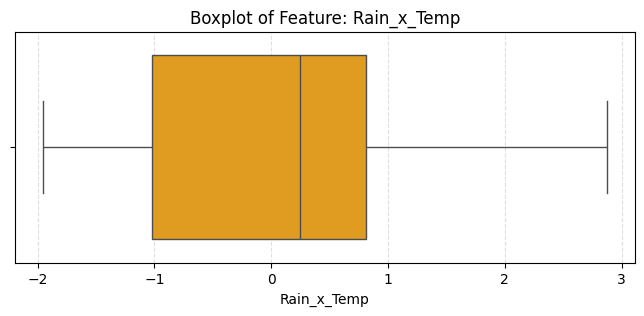

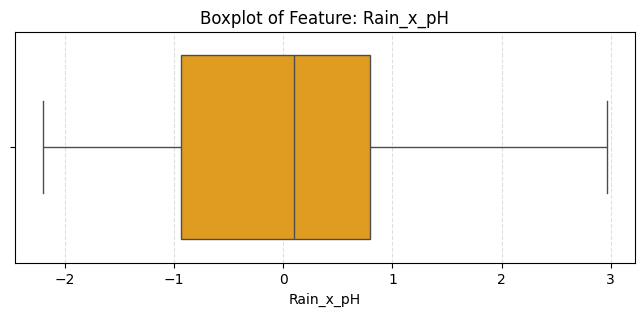

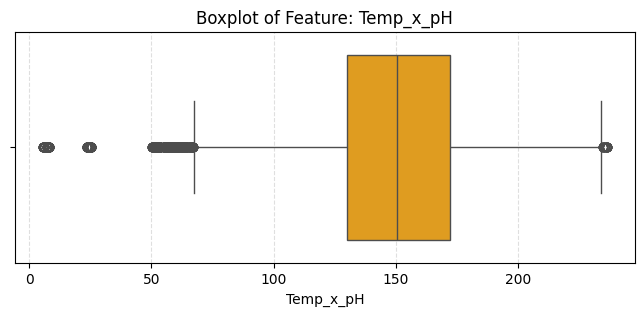

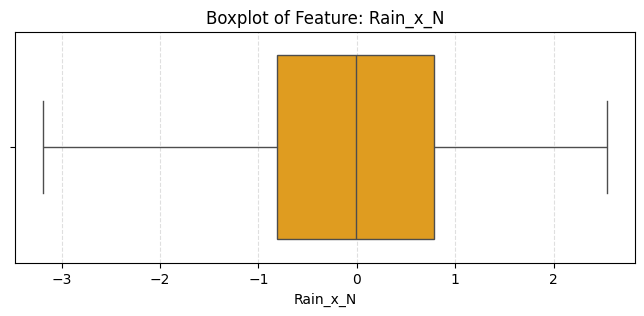

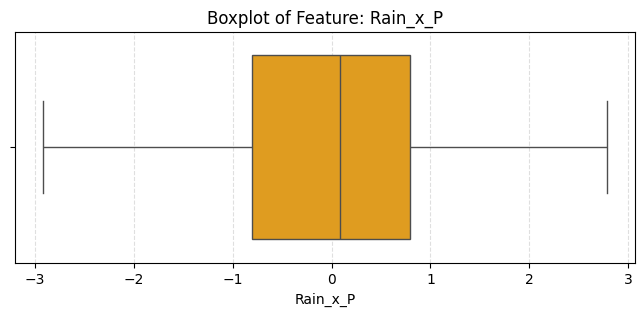

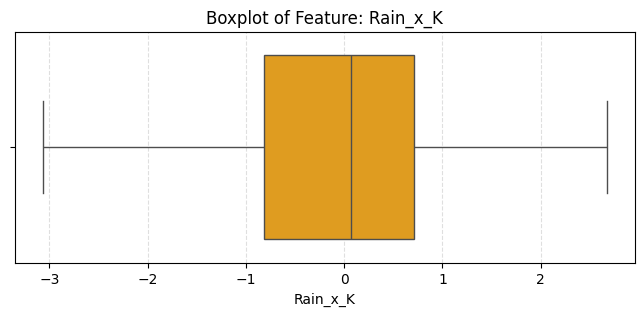

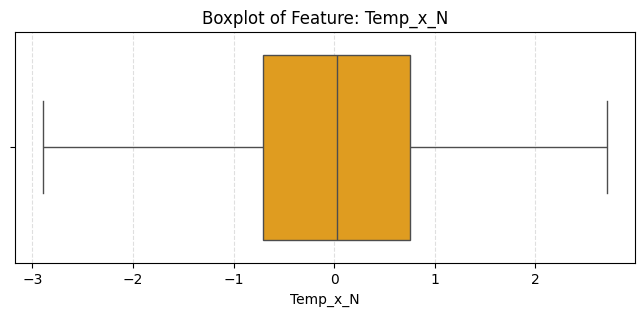

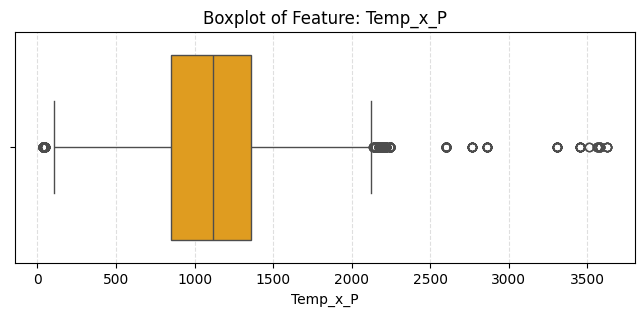

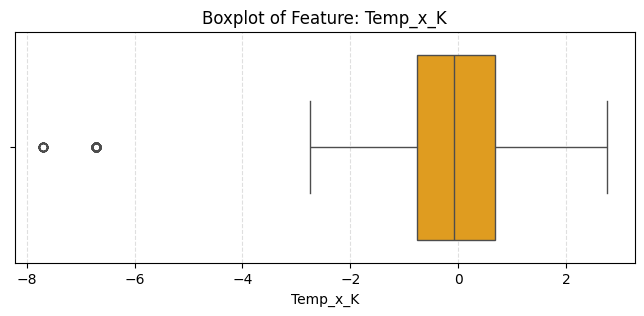

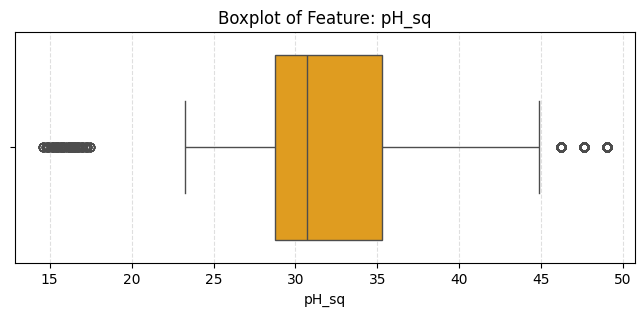

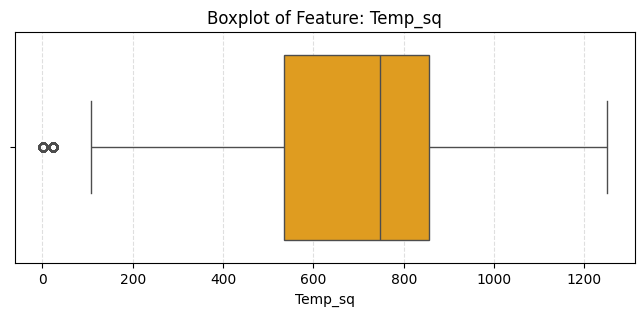

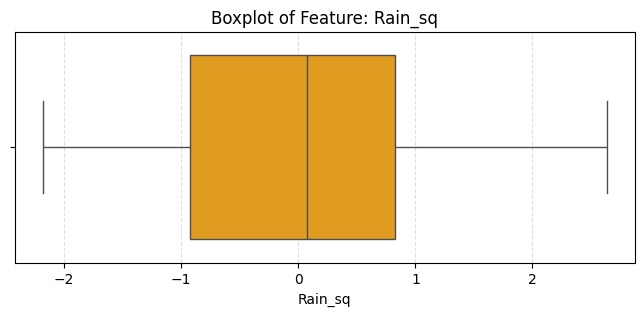

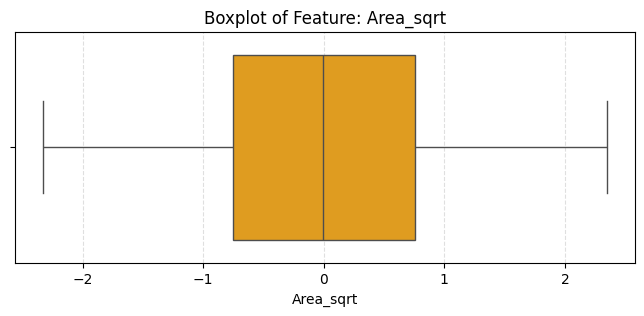

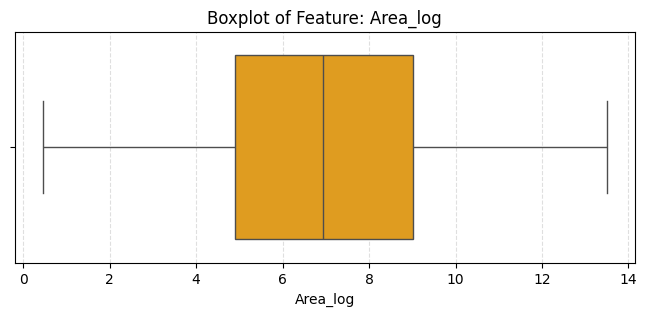

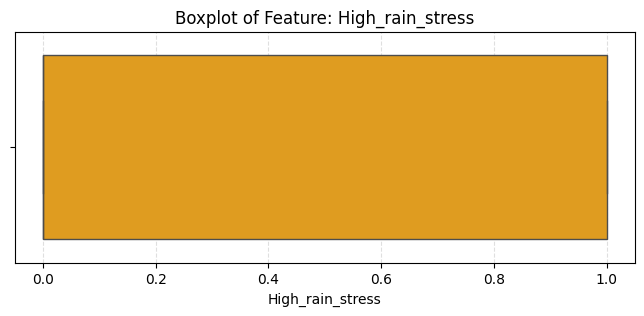

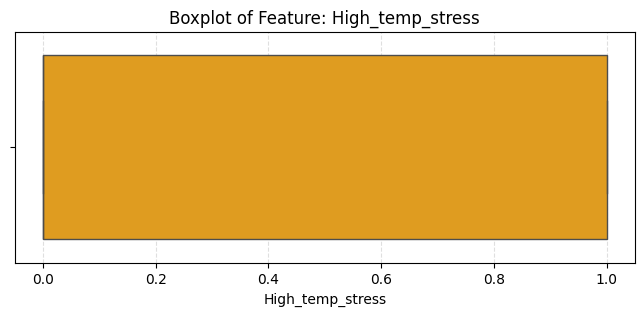

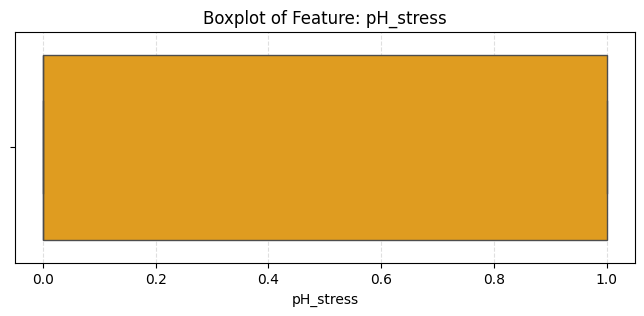

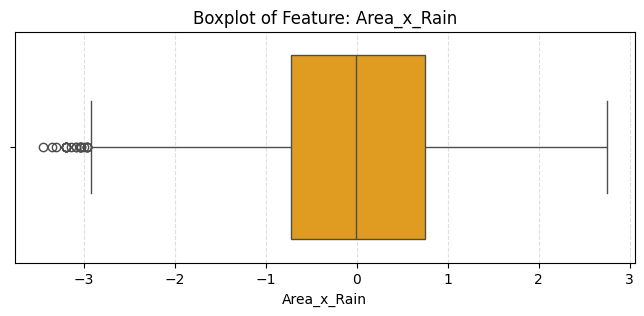

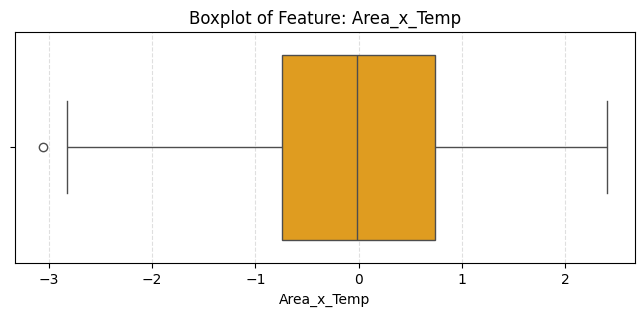

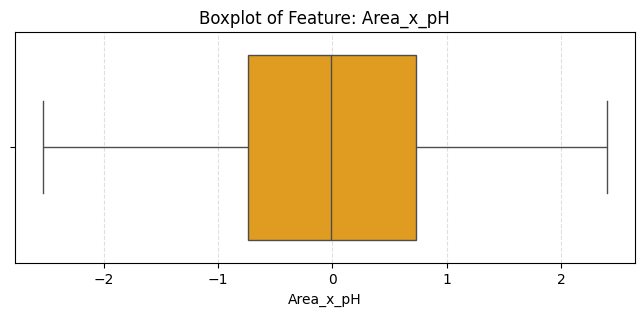

In [28]:
# -------------------------------------
# Boxplots for ALL Numeric Features
# -------------------------------------
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=X_train[col], color='orange')

    plt.title(f"Boxplot of Feature: {col}", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.show()


In [29]:
# Transform target with log1p on train only, then transform val/test using same logic
y_train = np.log1p(y_train_orig)
y_val = np.log1p(y_val_orig)
y_test = np.log1p(y_test_orig)

In [30]:
# Prepare DNN formats (transposed)
X_train_dnn = X_train_scaled.T
y_train_dnn = y_train.reshape(1, -1)
X_val_dnn = X_val_scaled.T
y_val_dnn = y_val.reshape(1, -1)
X_test_dnn = X_test_scaled.T

In [31]:
# Baseline training & evaluation (use transformed target for training)

baseline_results = {}


def safe_inverse_transform(pred_tr):
    pred_tr = np.clip(pred_tr, -15, None)  # allow small negatives but prevent explosion
    return np.expm1(pred_tr)

def safe_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))




rf_baseline = RandomForestRegressor(
    n_estimators=80,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt"
)

rf_baseline.fit(X_train_scaled, y_train)

rf_pred_tr = rf_baseline.predict(X_test_scaled)     # DO NOT clamp to 0
rf_pred_orig = safe_inverse_transform(rf_pred_tr)   # correct way to invert

baseline_results['Random Forest'] = {
    'MSE': mean_squared_error(y_test_orig, rf_pred_orig),
    'RMSE': safe_rmse(y_test_orig, rf_pred_orig),
    'MAE': mean_absolute_error(y_test_orig, rf_pred_orig),
    'R2': r2_score(y_test_orig, rf_pred_orig)
}
print("RF baseline RMSE:", baseline_results['Random Forest']['RMSE'])


gb_baseline = GradientBoostingRegressor(
    n_estimators=80,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    subsample=0.8,
    colsample=0.8,
    reg_lambda=0.1,
    early_stopping_rounds=10
)

gb_baseline.fit(X_train_scaled, y_train, X_val_scaled, y_val)

gb_pred_tr = gb_baseline.predict(X_test_scaled)
gb_pred_orig = safe_inverse_transform(gb_pred_tr)

baseline_results['Gradient Boosting'] = {
    'MSE': mean_squared_error(y_test_orig, gb_pred_orig),
    'RMSE': safe_rmse(y_test_orig, gb_pred_orig),
    'MAE': mean_absolute_error(y_test_orig, gb_pred_orig),
    'R2': r2_score(y_test_orig, gb_pred_orig)
}
print("GB baseline RMSE :", baseline_results['Gradient Boosting']['RMSE'])


dnn_baseline = Deep_Neural_Network()
dnn_baseline.create(
    input_size=X_train_dnn.shape[0],
    output_size=1,
    hidden_dims=[128, 64, 32],
    initializer='he',
    activation='relu',
    seed=RND
)

dnn_baseline.train(
    X_train_dnn, y_train_dnn,
    X_val_dnn, y_val_dnn,
    optimizer='adam',
    regularizer_lambda=0.001,
    mini_batch_size=64,
    epochs=50,
    learning_rate=0.001,
    print_loss_freq=25,
    plot_loss=False
)

dnn_pred_tr = dnn_baseline.predict(X_test_dnn).flatten()
dnn_pred_orig = safe_inverse_transform(dnn_pred_tr)

baseline_results['Deep Neural Network'] = {
    'MSE': mean_squared_error(y_test_orig, dnn_pred_orig),
    'RMSE': safe_rmse(y_test_orig, dnn_pred_orig),
    'MAE': mean_absolute_error(y_test_orig, dnn_pred_orig),
    'R2': r2_score(y_test_orig, dnn_pred_orig)
}
print("DNN baseline RMSE :", baseline_results['Deep Neural Network']['RMSE'])


pd.DataFrame(baseline_results).T


RF baseline RMSE: 55702.37106154095
GB baseline RMSE : 59393.99013772271
Epoch 25/50 - train: 0.160333, val: 0.187797
Epoch 50/50 - train: 0.138470, val: 0.166416
DNN baseline RMSE : 42067.1915089415


,MSE,RMSE,MAE,R2
Random Forest,3.102754e+09,55702.371062,13323.295316,0.781882
Gradient Boosting,3.527646e+09,59393.990138,14158.160740,0.752013
Deep Neural Network,1.769649e+09,42067.191509,10999.926255,0.875597


In [32]:
# Optuna setup
optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=RND, multivariate=True)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5)


In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_cache = {}

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 5, 12),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }

    key = tuple(sorted(params.items()))
    if key in rf_cache:
        return rf_cache[key]["rmse"]       # Optuna optimizes only RMSE

    kf = KFold(n_splits=3, shuffle=True, random_state=RND)

    rmse_list = []
    mae_list = []
    r2_list = []

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled)):
        X_tr, X_v = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_v = y_train[train_idx], y_train[val_idx]

        model = RandomForestRegressor(**params)
        model.fit(X_tr, y_tr)

        pred_scaled = model.predict(X_v)

        # Convert predictions and true values back to original scale
        pred_orig = to_original_target(pred_scaled)
        y_v_orig = to_original_target(y_v)

        # Calculate ALL metrics
        rmse = safe_rmse(y_v_orig, pred_orig)
        mae = mean_absolute_error(y_v_orig, pred_orig)
        r2 = r2_score(y_v_orig, pred_orig)

        rmse_list.append(rmse)
        mae_list.append(mae)
        r2_list.append(r2)

        trial.report(rmse, fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()

    # Mean metrics across folds
    results = {
        "rmse": float(np.mean(rmse_list)),
        "mae": float(np.mean(mae_list)),
        "r2": float(np.mean(r2_list))
    }

    rf_cache[key] = results
    return results["rmse"]   # Optuna still minimizes RMSE


study_rf = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='RF_Opt')
study_rf.optimize(objective_rf, n_trials=6, show_progress_bar=True)
print("RF best RMSE (orig scale):", study_rf.best_value)
print("RF best params:", study_rf.best_params)


  0%|          | 0/6 [00:00<?, ?it/s]

RF best RMSE (orig scale): 45324.759439866604
RF best params: {'n_estimators': 87, 'max_depth': 12, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'sqrt'}


In [34]:
best_params = study_rf.best_params
key = tuple(sorted(best_params.items()))
best_scores = rf_cache[key]

print("\n===== Best Random Forest Metrics =====")
print("RMSE:", best_scores["rmse"])
print("MAE :", best_scores["mae"])
print("R²  :", best_scores["r2"])
print("Best Parameters:", best_params)



===== Best Random Forest Metrics =====
RMSE: 45324.759439866604
MAE : 10566.327512918038
R²  : 0.8593221144147858
Best Parameters: {'n_estimators': 87, 'max_depth': 12, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'sqrt'}


In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

gb_cache = {}

def objective_gb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.03, 0.2),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 2, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0)
    }

    key = tuple(sorted(params.items()))
    if key in gb_cache:
        return gb_cache[key]["rmse"]   # Optuna optimizes RMSE

    kf = KFold(n_splits=3, shuffle=True, random_state=RND)

    rmse_list = []
    mae_list = []
    r2_list = []

    for train_idx, val_idx in kf.split(X_train_scaled):
        X_tr, X_v = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_tr, y_v = y_train[train_idx], y_train[val_idx]

        model = GradientBoostingRegressor(
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            min_samples_leaf=params['min_samples_leaf'],
            subsample=params['subsample']
        )

        model.fit(X_tr, y_tr)
        pred_scaled = model.predict(X_v)

        pred_orig = to_original_target(pred_scaled)
        y_v_orig = to_original_target(y_v)

        # Evaluation metrics
        rmse = safe_rmse(y_v_orig, pred_orig)
        mae = mean_absolute_error(y_v_orig, pred_orig)
        r2  = r2_score(y_v_orig, pred_orig)

        rmse_list.append(rmse)
        mae_list.append(mae)
        r2_list.append(r2)

    results = {
        "rmse": float(np.mean(rmse_list)),
        "mae": float(np.mean(mae_list)),
        "r2": float(np.mean(r2_list))
    }

    gb_cache[key] = results
    return results["rmse"]


study_gb = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='GB_Opt')
study_gb.optimize(objective_gb, n_trials= 6, show_progress_bar=True)
print("GB best RMSE (orig scale):", study_gb.best_value)
print("GB best params:", study_gb.best_params)


  0%|          | 0/6 [00:00<?, ?it/s]

GB best RMSE (orig scale): 39244.47209124623
GB best params: {'n_estimators': 108, 'learning_rate': 0.0761293354015623, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 4, 'subsample': 0.8170784332632994}


In [36]:
best_params = study_gb.best_params
key = tuple(sorted(best_params.items()))
best_scores = gb_cache[key]

print("\n===== Best Gradient Boosting Metrics =====")
print("RMSE:", best_scores["rmse"])
print("MAE :", best_scores["mae"])
print("R²  :", best_scores["r2"])
print("Best Parameters:", best_params)



===== Best Gradient Boosting Metrics =====
RMSE: 39244.47209124623
MAE : 9549.341303804618
R²  : 0.8942406273420772
Best Parameters: {'n_estimators': 108, 'learning_rate': 0.0761293354015623, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 4, 'subsample': 0.8170784332632994}


In [37]:
from sklearn.metrics import mean_absolute_error, r2_score

dnn_cache = {}

def objective_dnn(trial):

    params = {
        'layer1': trial.suggest_int('layer1', 64, 160),
        'layer2': trial.suggest_int('layer2', 32, 96),
        'layer3': trial.suggest_int('layer3', 16, 48),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 5e-3, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 1e-3, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64]),
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh'])
    }

    # unique caching key
    key = tuple(params.values())
    if key in dnn_cache:
        return dnn_cache[key]["rmse"]   # Optuna optimizes RMSE only

    # Training and validation sets
    X_tr = X_train_scaled.T
    y_tr = y_train.reshape(1, -1)

    X_v = X_val_scaled.T
    y_v = y_val.reshape(1, -1)

    # Build model
    model = Deep_Neural_Network()
    model.create(
        input_size=X_tr.shape[0],
        output_size=1,
        hidden_dims=[params['layer1'], params['layer2'], params['layer3']],
        initializer='he',
        activation=params['activation'],
        seed=RND
    )

    # Train model
    model.train(
        X_tr, y_tr,
        X_v, y_v,
        optimizer='adam',
        regularizer_lambda=params['reg_lambda'],
        mini_batch_size=params['batch_size'],
        epochs=30,
        learning_rate=params['learning_rate'],
        print_loss_freq=15,
        plot_loss=False
    )

    # Predictions
    pred_scaled = model.predict(X_v).flatten()
    pred_orig = to_original_target(pred_scaled)
    y_v_orig = to_original_target(y_v.flatten())

    # Metrics
    rmse = safe_rmse(y_v_orig, pred_orig)
    mae  = mean_absolute_error(y_v_orig, pred_orig)
    r2   = r2_score(y_v_orig, pred_orig)

    # Store all metrics in cache
    dnn_cache[key] = {
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

    return rmse   # Optuna minimizes RMSE
study_dnn = optuna.create_study(direction='minimize', sampler=sampler, pruner=pruner, study_name='DNN_Opt')
study_dnn.optimize(objective_dnn, n_trials=6, show_progress_bar=True)
print("DNN best RMSE (orig scale):", study_dnn.best_value)
print("DNN best params:", study_dnn.best_params)

  0%|          | 0/6 [00:00<?, ?it/s]

Epoch 15/30 - train: 1.775522, val: 1.808861
Epoch 30/30 - train: 1.815074, val: 1.857990
Epoch 15/30 - train: 0.272315, val: 0.297613
Epoch 30/30 - train: 0.186296, val: 0.211724
Epoch 15/30 - train: 0.210919, val: 0.241033
Epoch 30/30 - train: 0.156947, val: 0.182358
Epoch 15/30 - train: 1.910720, val: 1.941219
Epoch 30/30 - train: 1.854250, val: 1.877217
Epoch 15/30 - train: 0.307290, val: 0.329119
Epoch 30/30 - train: 0.251007, val: 0.277144
Epoch 15/30 - train: 1.837612, val: 1.927048
Epoch 30/30 - train: 1.898895, val: 2.128905
DNN best RMSE (orig scale): 48968.21748078569
DNN best params: {'layer1': 124, 'layer2': 53, 'layer3': 18, 'learning_rate': 0.0003375589571206087, 'reg_lambda': 4.4706085467784903e-05, 'batch_size': 32, 'activation': 'relu'}


In [38]:
best_params = study_dnn.best_params

# recreate the key
key = tuple(best_params.values())

best_scores = dnn_cache[key]

print("\n===== Best DNN Metrics =====")
print("RMSE:", best_scores["rmse"])
print("MAE :", best_scores["mae"])
print("R²  :", best_scores["r2"])
print("Best Parameters:", best_params)



===== Best DNN Metrics =====
RMSE: 48968.21748078569
MAE : 11984.57404817894
R²  : 0.8604875256702333
Best Parameters: {'layer1': 124, 'layer2': 53, 'layer3': 18, 'learning_rate': 0.0003375589571206087, 'reg_lambda': 4.4706085467784903e-05, 'batch_size': 32, 'activation': 'relu'}


Epoch 25/120 - train: 0.200675, val: 0.226318
Epoch 50/120 - train: 0.170696, val: 0.196932
Epoch 75/120 - train: 0.178677, val: 0.206883
Epoch 100/120 - train: 0.156594, val: 0.183288


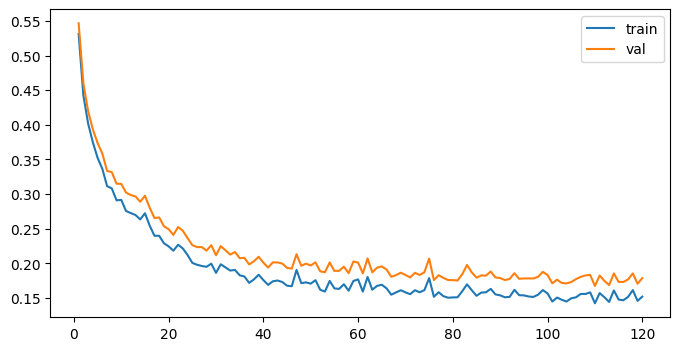


===== FINAL METRICS (All Models) =====


,MSE,RMSE,MAE,R2
Random Forest,3.102754e+09,55702.371062,13323.295316,0.781882
Gradient Boosting,3.527646e+09,59393.990138,14158.160740,0.752013
Deep Neural Network,1.769649e+09,42067.191509,10999.926255,0.875597
Random Forest (Optimized),1.458859e+09,38195.017823,9682.203504,0.897445
Gradient Boosting (Optimized),1.147661e+09,33877.152107,9095.564618,0.919322
Deep Neural Network (Optimized),1.792281e+09,42335.337490,11403.639012,0.874006


In [39]:
# %% Cell 15 - Final training with best params (metrics on original scale)
optimized_results = {}

# ---------------------------------------------
# RANDOM FOREST (Optimized)
# ---------------------------------------------
rf_opt = RandomForestRegressor(**study_rf.best_params)
rf_opt.fit(X_train_scaled, y_train)
rf_opt_pred = rf_opt.predict(X_test_scaled)
rf_opt_pred_orig = to_original_target(rf_opt_pred)

optimized_results['Random Forest (Optimized)'] = {
    'MSE' : mean_squared_error(y_test_orig, rf_opt_pred_orig),
    'RMSE': safe_rmse(y_test_orig, rf_opt_pred_orig),
    'MAE' : mean_absolute_error(y_test_orig, rf_opt_pred_orig),
    'R2'  : r2_score(y_test_orig, rf_opt_pred_orig)
}


# ---------------------------------------------
# GRADIENT BOOSTING (Optimized)
# ---------------------------------------------
gb_params = study_gb.best_params.copy()
gb_opt = GradientBoostingRegressor(**gb_params)

gb_opt.fit(X_train_scaled, y_train)
gb_opt_pred = gb_opt.predict(X_test_scaled)
gb_opt_pred_orig = to_original_target(gb_opt_pred)

optimized_results['Gradient Boosting (Optimized)'] = {
    'MSE' : mean_squared_error(y_test_orig, gb_opt_pred_orig),
    'RMSE': safe_rmse(y_test_orig, gb_opt_pred_orig),
    'MAE' : mean_absolute_error(y_test_orig, gb_opt_pred_orig),
    'R2'  : r2_score(y_test_orig, gb_opt_pred_orig)
}


# ---------------------------------------------
# DEEP NEURAL NETWORK (Optimized)
# ---------------------------------------------
dnn_p = study_dnn.best_params

dnn_final = Deep_Neural_Network()
dnn_final.create(
    input_size=X_train_dnn.shape[0],
    output_size=1,
    hidden_dims=[dnn_p['layer1'], dnn_p['layer2'], dnn_p['layer3']],
    activation=dnn_p['activation'],
    initializer='he',
    seed=RND
)

dnn_final.train(
    X_train_dnn, y_train_dnn,
    X_val_dnn, y_val_dnn,
    optimizer='adam',
    regularizer_lambda=dnn_p['reg_lambda'],
    mini_batch_size=dnn_p['batch_size'],
    epochs=120,
    learning_rate=dnn_p['learning_rate'],
    print_loss_freq=25,
    plot_loss=True
)

dnn_pred = dnn_final.predict(X_test_dnn).flatten()
dnn_pred_orig = to_original_target(dnn_pred)

optimized_results['Deep Neural Network (Optimized)'] = {
    'MSE' : mean_squared_error(y_test_orig, dnn_pred_orig),
    'RMSE': safe_rmse(y_test_orig, dnn_pred_orig),
    'MAE' : mean_absolute_error(y_test_orig, dnn_pred_orig),
    'R2'  : r2_score(y_test_orig, dnn_pred_orig)
}


# ---------------------------------------------
# COMBINE BASELINE + OPTIMIZED
# ---------------------------------------------
all_results = {**baseline_results, **optimized_results}
results_df = pd.DataFrame(all_results).T

print("\n===== FINAL METRICS (All Models) =====")
display(results_df)
